# Directional Consensus (DC): scoring NL→FOL faithfulness without gold

This notebook demos the experiment **"Checking a formula against its peers on fresh data"**: a
*freeze-then-confirm* test of **Directional Consensus (DC)**, a gold-free, text-blind score for how faithful
a first-order-logic (FOL) formalization is to its natural-language sentence.

**The idea.** Several different systems (9 LLMs here) formalize the same sentence. Their predicate names
never match (`AppleMade(x)` vs `MadeBy(x, apple)`). So DC compares formulas **without reading names**:
1. **Lexical-free alignment.** It searches maps of symbols between two formulas: an L1 arity-preserving
   bijection, or an L2 partial map (a B-only predicate stays *fresh*). Maps are ranked by a structural
   fingerprint and screened on random finite structures.
2. **Solver relation.** Under the best map, z3 decides the entailment relation: EQUIV / STRONGER / WEAKER /
   INCOMPARABLE / CONTRADICTORY (UNALIGNABLE when no map covers ≥50% of the symbols).
3. **Consensus.** `DC(C) = Σ_p w_p·1[C ≡ p] / Σ_p w_p` over covered peers. `w_p` are label-free one-coin
   Dawid–Skene reliability weights fitted on the EQUIV clusters.
4. **Error typing.** A non-modal candidate is diffed against the modal cluster's representative to name
   an error type (dropped/added condition, quantifier, negation, argument swap, …).

**The experiment.** The DC configuration was **frozen on 700 dev sentences** (L3 granularity off,
UNALIGNABLE counted in the denominator, DS weights; sha256 receipt) *before* fresh labels existed. It was
then confirmed on **450 overlap-free sentences** (MALLS, FOLIO-v2-train, ProverQA) × 9 systems:
DC AUROC **0.827** (blinded LLM panel) / **0.874** (audited-solver labels).

**What this notebook runs.** The original `method.py` is a stage dispatcher. Its stages call paid APIs, a
GPU model and a 95 MB pair cache. Here we run the **core DC library (`dc/`) verbatim** on a curated subset
of the labelled fresh set: 11 sentences × 9 systems = 99 labelled candidates. The notebook recomputes every
pairwise alignment with z3, scores DC under the frozen config, types errors, and checks AUROC against the
labels next to the stored baselines.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0')

# numpy, scikit-learn, matplotlib, pandas — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0', 'pandas==2.2.2')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The original import block of `method.py`, plus the imports of every library module that is inlined below
(`vendor/ds/src/fol_parse.py`, `vendor/ds/src/fol_equiv.py`, `dc/*.py`). In the original repo these are
separate modules. Here they share the notebook namespace, so their `from .x import y` lines become plain
names. Last come the notebook-only imports for evaluation and plots.

In [2]:
# --- method.py (original)
import argparse
import subprocess
import sys
from pathlib import Path

# --- vendor/ds/src/fol_parse.py, vendor/ds/src/fol_equiv.py, dc/*.py (original module imports)
import heapq
import itertools
import math
import random
import re
import time
from collections import defaultdict
from dataclasses import asdict, dataclass, field
from functools import lru_cache

import z3

# --- notebook-only (evaluation + visualisation)
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## Data loading
The data is loaded from GitHub, with a fallback to a local `mini_demo_data.json`. The helper only accepts this experiment's file (`fresh_confirm_greedy_450x9`).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-2/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            d = json.loads(response.read().decode())
        # guard: before this demo is pushed, the URL may still serve an older file from another experiment
        if "fresh_confirm_greedy_450x9" in d.get("metadata", {}).get("source", ""):
            return d
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
print(meta["source"])
print("examples:", meta["n_examples"], "| sentences:", meta["n_sentences"])
print("frozen config:", meta["frozen_config_name"], meta["frozen_config"])
print("frozen config sha256:", meta["frozen_config_sha256"])
ex0 = data["examples"][0]
print("\nexample row:", json.loads(ex0["input"]), "->", ex0["output"])

full_method_out.json -> datasets[0] fresh_confirm_greedy_450x9 (artifact art_D-NE4j8Hew3l)
examples: 99 | sentences: 11
frozen config: L3off_UAin_DS_caps1 {'use_L3': False, 'unalign_in_denominator': True, 'weights': 'DS', 'half_caps': False, 'rule_1b': False}
frozen config sha256: 31888cb8f0de0c47e1b8584174415bf211cc4395b101c35fe217a3dac707e6a7

example row: {'sentence': 'Some books have illustrations.', 'candidate_fol': '∃x (Book(x) ∧ HasIllustration(x))'} -> faithful


## Configuration

All tunable parameters are here. `N_SENTENCES` controls the demo size. Each sentence brings its 9 system
outputs and costs up to 36 pairwise alignments. The `Caps` values are the original `dc/align.py`
defaults. They are search and time caps: most pairs finish well below them, so they rarely change a
result. The DC configuration itself (`use_L3`, `unalign_in_denominator`, `weights`, `half_caps`,
`rule_1b`) is the **frozen** one shipped in the data. It must not be tuned: freezing it before seeing
fresh labels is the point of the experiment.

In [5]:
N_SENTENCES = 11           # sentences to score (each = 9 systems); demo data has 11 (full run: 450)
WITH_TYPE = True             # also run DC error typing (dc/errtype.py) for non-modal candidates

# alignment / solver caps (original dc.align.Caps defaults)
CAP_L1 = 5040                # max L1 bijections tried per pair
CAP_L2 = 2000                # max L2 partial maps tried per pair
CAP_L3 = 300                 # max L3 granularity splits (L3 is OFF in the frozen config)
Z3_EQUIV_ATTEMPTS = 40       # max maps sent to z3 for an EQUIV proof per level
PAIR_WALL_S = 20.0           # wall-clock budget per formula pair (seconds)
MIN_SHARE = 0.5              # L2 map must cover >= 50% of symbol occurrences of both formulas

# DS weights: the frozen procedure refits them label-free on the fresh EQUIV clusters of ALL 450 sentences.
# With only a handful of demo sentences a refit is noisy, so by default we use the stored fresh weights.
USE_STORED_FRESH_WEIGHTS = True

## The original entry point: `method.py`

`method.py` only runs the pipeline stages in order. Each stage is a script in `src/` and every API call is
cached. It is kept here nearly verbatim (only `ROOT` changes, because a notebook has no `__file__`). It is
**not executed**: the stages need OpenRouter keys (generation, labels, the B1 judge), a GPU (Qwen3-8B
baselines) and the `work/` caches. The printout shows the offline stage plan. The cells after it run the
heart of the `devpairs → fresh → scores` stages, the DC library, directly.

In [6]:
ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
PY = sys.executable
STAGES = {
    "sample": [["s01_sample_fresh.py"]],
    "generate": [["s02_generate.py", "--cap", "0.9"]],
    "devframe": [["s03_dev_frame.py"]],
    "devpairs": [["pairs.py", "../work/dev_pair_jobs.jsonl"], ["pairs.py", "../work/dev_within_jobs.jsonl"]],
    "freeze": [["s04_freeze.py"]],
    "fresh": [["s05_fresh.py", c] for c in ("frame", "dcpairs", "lcpairs", "lc", "b7", "vc")],
    "gate": [["s06_labels.py", "gate", "--cap", "0.35"]],
    "labels": [["s06_labels.py", "l0", "--cap", "0.9"], ["s06_labels.py", "l1"],
               ["s06_labels.py", "l3", "--n", "272", "--n_unparse", "12", "--cap", "1.05"]],
    "llm": [["s09_llm_baselines.py", "b1", "--cap", "0.25"]],
    "local": [["s09b_local.py"]],
    "scores": [["s10_scores.py"]],
    "tests": [["s11_tests.py"]],
    "secondary": [["s12_secondary.py"], ["s12b_extra.py"], ["s12c_perturb.py"], ["report_tables.py"]],
    "export": [["s13_export.py"]],
}
OFFLINE = ["devframe", "devpairs", "freeze", "fresh", "local", "scores", "tests", "secondary", "export"]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", required=True, choices=list(STAGES) + ["all_offline"])
    a = ap.parse_args()
    todo = OFFLINE if a.stage == "all_offline" else [a.stage]
    for st in todo:
        if st == "freeze" and (ROOT / "results" / "frozen_config.json").exists():
            print("== freeze: receipt exists (results/frozen_config.json) -> not re-frozen", flush=True)
            continue
        for cmd in STAGES[st]:
            print(f"== {st}: {' '.join(cmd)}", flush=True)
            r = subprocess.run([PY, *cmd], cwd=ROOT / "src")
            if r.returncode != 0:
                sys.exit(f"stage {st} failed ({' '.join(cmd)}), exit {r.returncode}")


# notebook: main() is not called (it shells out to the src/ stage scripts); show the stage plan instead
for st in OFFLINE:
    print(f"{st:10s}", " ; ".join(" ".join(c) for c in STAGES[st]))

devframe   s03_dev_frame.py
devpairs   pairs.py ../work/dev_pair_jobs.jsonl ; pairs.py ../work/dev_within_jobs.jsonl
freeze     s04_freeze.py
fresh      s05_fresh.py frame ; s05_fresh.py dcpairs ; s05_fresh.py lcpairs ; s05_fresh.py lc ; s05_fresh.py b7 ; s05_fresh.py vc
local      s09b_local.py
scores     s10_scores.py
tests      s11_tests.py
secondary  s12_secondary.py ; s12b_extra.py ; s12c_perturb.py ; report_tables.py
export     s13_export.py


## Library 1/8: tolerant FOL parser (`vendor/ds/src/fol_parse.py`)

This is the dataset's parser, reused so every system's dialect (unicode, ASCII, LaTeX, snake_case) is
read the same way the labels were built. It produces a hashable tuple AST:
`('forall', v, body)`, `('atom', name, terms)`, `('imp', a, b)`, and so on.

In [7]:
"""Tolerant first-order-logic parser / printer for NL->FOL outputs.

Extended from the GEN_HYPO feasibility prototype
(iter_1/gen_hypo/claude_agent/feasibility/monotonicity_profile.py, Pratt parser).

Accepted syntax
- Quantifiers: ∀ ∃ and ASCII `forall` `exists` (also `all`/`some` when followed by a variable
  and a formula); multi-binders `∀x ∀y`, `∀x,y`, `∀x y`, `∀x.` `∀x:` `(∀x)`.
- Connectives: ¬ ~ ! not | ∧ & and | ∨ | or | → -> => ⇒ ⊃ | ↔ <-> <=> ⇔ ≡ | ⊕ xor ^ ⊻.
- Equality `=`, `≠`, `!=`. Predicates in CamelCase or snake_case; 0-ary propositions.
- Constants: any argument identifier that is not bound by an enclosing quantifier.
- Unsupported (parse error): function terms, ∈ ⊆ < > and arithmetic.

AST (hashable tuples)
  ('forall', var, body) ('exists', var, body) ('not', a) ('and', a, b) ('or', a, b)
  ('imp', a, b) ('iff', a, b) ('xor', a, b) ('atom', name, (term, ...)) ('eq', t1, t2)
  term = ('var', name) | ('const', name)

Scope policy: a quantifier followed by '(' scopes over that group (FOLIO convention). If the
result leaves variables free that a quantifier binds elsewhere, the formula is re-parsed with
WIDE scope (quantifier body extends to the right as far as possible); remaining free
single-letter variables are universally closed. Both repairs are reported in `ParseResult.notes`.
"""


QUANT = {"∀": "forall", "∃": "exists", "forall": "forall", "exists": "exists", "exist": "exists",
         "all": "forall", "some": "exists", "∀∀": "forall"}
NOT_TOK = {"¬", "~", "!", "not", "∼", "￢"}
BIN = {
    "∧": "and", "&": "and", "&&": "and", "and": "and", "/\\": "and", "⋀": "and",
    "∨": "or", "|": "or", "||": "or", "or": "or", "\\/": "or", "⋁": "or",
    "→": "imp", "->": "imp", "=>": "imp", "⇒": "imp", "⊃": "imp", "⟶": "imp", "implies": "imp",
    "↔": "iff", "<->": "iff", "<=>": "iff", "⇔": "iff", "≡": "iff", "⟷": "iff", "iff": "iff",
    "⊕": "xor", "xor": "xor", "⊻": "xor", "^": "and",  # ASCII ^ is read as conjunction (∧ look-alike)
}
PREC = {"iff": 1, "xor": 1, "imp": 2, "or": 3, "and": 4}
SYM = {"and": "∧", "or": "∨", "imp": "→", "iff": "↔", "xor": "⊕"}

TOK_RE = re.compile(
    r"\s*(<->|<=>|->|=>|&&|\|\||/\\|\\/|!=|≠|∀|∃|¬|∧|∨|→|↔|⊕|⇒|⇔|⊃|≡|⊻|⟶|⟷|⋀|⋁|∼|￢|"
    r"[~!&|^()\[\],.:=]|∈|⊆|⊂|<|>|≤|≥|\+|\*|/|-|"
    r"\"[^\"]{0,60}\"|[0-9]+\.[0-9]+[A-Za-z0-9_%]*|"
    r"[A-Za-z0-9_À-ɏ]+(?:['\-][A-Za-z0-9_À-ɏ]+)*)"
)
VARLIKE = re.compile(r"^[a-z][0-9]{0,2}'*$")  # x, y1, z12, x' ; NOT yr2028 / p1080 (constants)


class FOLParseError(ValueError):
    pass


@dataclass
class ParseResult:
    ast: tuple | None
    ok: bool
    error: str = ""
    notes: list[str] = field(default_factory=list)
    text: str = ""


def tokenize(s: str) -> list[str]:
    out, pos = [], 0
    s = s.strip()
    while pos < len(s):
        m = TOK_RE.match(s, pos)
        if not m or m.end() == pos:
            raise FOLParseError(f"cannot tokenize at {s[pos:pos + 20]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


def _is_ident(t: str | None) -> bool:
    return t is not None and bool(re.match(r"^[\"A-Za-z0-9_À-ɏ]", t)) \
        and t.lower() not in ("and", "or", "not", "xor", "implies", "iff") and t not in QUANT


class _Parser:
    def __init__(self, toks: list[str], wide: bool):
        self.t, self.i, self.wide = toks, 0, wide

    def peek(self, k: int = 0):
        j = self.i + k
        return self.t[j] if j < len(self.t) else None

    def eat(self, x: str | None = None) -> str:
        tok = self.peek()
        if tok is None:
            raise FOLParseError(f"unexpected end (expected {x})" if x else "unexpected end")
        if x is not None and tok != x:
            raise FOLParseError(f"expected {x!r} got {tok!r}")
        self.i += 1
        return tok

    def binop(self) -> str | None:
        tok = self.peek()
        if tok is None:
            return None
        return BIN.get(tok) or BIN.get(tok.lower()) if (tok in BIN or tok.lower() in BIN) else None

    def parse_formula(self, minp: int = 1) -> tuple:
        lhs = self.unary()
        while True:
            op = self.binop()
            if op is None or PREC[op] < minp:
                break
            self.eat()
            p = PREC[op]
            rhs = self.parse_formula(p if op == "imp" else p + 1)
            lhs = (op, lhs, rhs)
        return lhs

    def is_quant_start(self) -> bool:
        tok = self.peek()
        if tok in ("∀", "∃"):
            return True
        if tok is not None and tok.lower() in ("forall", "exists", "exist"):
            return True
        if tok is not None and tok.lower() in ("all", "some"):
            nxt, nxt2 = self.peek(1), self.peek(2)
            return nxt is not None and bool(VARLIKE.match(nxt)) and nxt2 not in (")", ",", None)
        return False

    def binders(self) -> list[str]:
        vars_ = []
        while True:
            tok = self.peek()
            if tok is None:
                raise FOLParseError("quantifier without variable")
            if not _is_ident(tok):
                raise FOLParseError(f"bad quantified variable {tok!r}")
            self.eat()
            vars_.append(tok)
            nxt = self.peek()
            if nxt == ",":
                # ∀x,y (...)  -- only if an identifier that is not a predicate call follows
                call_like = self.peek(2) == "(" and _is_ident(self.peek(3)) and self.peek(4) in (",", ")")
                if _is_ident(self.peek(1)) and (self.peek(2) != "(" or (VARLIKE.match(self.peek(1)) and not call_like)):
                    self.eat(",")
                    continue
                self.eat(",")
                break
            if nxt in (".", ":"):
                self.eat()
                break
            # ∀x y (...)  : a following lowercase var-like identifier not followed by '('
            if _is_ident(nxt) and VARLIKE.match(nxt) and self.peek(1) is not None \
                    and self.peek(1) not in BIN and self.peek(1) not in (")", ",", "=", "≠", "!="):
                looks_call = self.peek(1) == "(" and _is_ident(self.peek(2)) and self.peek(3) in (",", ")")
                if not looks_call:
                    continue
            break
        return vars_

    def unary(self) -> tuple:
        tok = self.peek()
        if tok is None:
            raise FOLParseError("unexpected end of formula")
        if self.is_quant_start():
            q = QUANT[tok.lower()] if tok.lower() in QUANT else QUANT[tok]
            self.eat()
            if self.peek() == "(" and _is_ident(self.peek(1)) and self.peek(2) == ")" :
                # ∀(x) body
                self.eat("(")
                vars_ = [self.eat()]
                self.eat(")")
            else:
                vars_ = self.binders()
            body = self.quant_body()
            for v in reversed(vars_):
                body = (q, v, body)
            return body
        if tok in NOT_TOK or tok.lower() == "not":
            self.eat()
            return ("not", self.unary())
        if tok in ("(", "["):
            close = ")" if tok == "(" else "]"
            # (∀x) body  -- parenthesised quantifier prefix
            if self.peek(1) in ("∀", "∃") and _is_ident(self.peek(2)) and self.peek(3) == close:
                self.eat(tok)
                q = QUANT[self.eat()]
                v = self.eat()
                self.eat(close)
                return (q, v, self.quant_body())
            self.eat(tok)
            n = self.parse_formula()
            self.eat(close)
            return n
        return self.atom()

    def quant_body(self) -> tuple:
        if self.wide:
            return self.parse_formula()
        tok = self.peek()
        if tok in ("(", "["):
            return self.unary()
        if self.is_quant_start() or tok in NOT_TOK:
            return self.unary()
        # "∀x P(x) → Q(x)" : without a group the body extends to the right (standard reading)
        return self.parse_formula()

    def term(self) -> tuple:
        tok = self.eat()
        if not _is_ident(tok):
            raise FOLParseError(f"bad term {tok!r}")
        if self.peek() == "(":
            raise FOLParseError(f"function term {tok}(...) unsupported")
        return ("t", tok)

    def atom(self) -> tuple:
        tok = self.peek()
        if not _is_ident(tok):
            raise FOLParseError(f"unexpected token {tok!r}")
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = []
            if self.peek() == ")":
                self.eat(")")
                return ("atom", name, tuple())
            while True:
                args.append(self.term())
                if self.peek() == ",":
                    self.eat(",")
                    continue
                self.eat(")")
                break
            return ("atom", name, tuple(args))
        # equality between bare terms
        if self.peek() in ("=", "≠", "!="):
            op = self.eat()
            rhs = self.term()
            eq = ("eq", ("t", name), rhs)
            return ("not", eq) if op in ("≠", "!=") else eq
        if self.peek() in ("∈", "⊆", "⊂", "<", ">", "≤", "≥"):
            raise FOLParseError(f"unsupported relation {self.peek()!r}")
        return ("atom", name, tuple())


def _resolve(n: tuple, bound: frozenset, free_vars: set) -> tuple:
    op = n[0]
    if op in ("forall", "exists"):
        return (op, n[1], _resolve(n[2], bound | {n[1]}, free_vars))
    if op == "not":
        return ("not", _resolve(n[1], bound, free_vars))
    if op in SYM:
        return (op, _resolve(n[1], bound, free_vars), _resolve(n[2], bound, free_vars))
    if op in ("atom", "eq"):
        terms = n[2] if op == "atom" else n[1:]
        res = []
        for t in terms:
            name = t[1]
            if name in bound:
                res.append(("var", name))
            else:
                if VARLIKE.match(name):
                    free_vars.add(name)
                res.append(("const", name))
        return ("atom", n[1], tuple(res)) if op == "atom" else ("eq", res[0], res[1])
    raise FOLParseError(f"bad node {op}")


def _bound_names(n: tuple, acc: set) -> set:
    if n[0] in ("forall", "exists"):
        acc.add(n[1])
        _bound_names(n[2], acc)
    elif n[0] == "not":
        _bound_names(n[1], acc)
    elif n[0] in SYM:
        _bound_names(n[1], acc)
        _bound_names(n[2], acc)
    return acc


def _close(ast: tuple, names: list[str]) -> tuple:
    for v in sorted(names, reverse=True):
        ast = ("forall", v, ast)
    return ast


def _to_var(n: tuple, names: set) -> tuple:
    op = n[0]
    if op in ("forall", "exists"):
        return (op, n[1], _to_var(n[2], names - {n[1]} if False else names))
    if op == "not":
        return ("not", _to_var(n[1], names))
    if op in SYM:
        return (op, _to_var(n[1], names), _to_var(n[2], names))
    if op == "atom":
        return ("atom", n[1], tuple(("var", t[1]) if t[0] == "const" and t[1] in names else t for t in n[2]))
    if op == "eq":
        return ("eq",) + tuple(("var", t[1]) if t[0] == "const" and t[1] in names else t for t in n[1:])
    return n


FENCE = re.compile(r"```[a-zA-Z]*")


LATEX_WRAP = re.compile(r"\\(?:text|mathrm|mathit|textit|operatorname|mathsf|texttt)\s*\{([^{}]*)\}")


def clean_text(s: str) -> str:
    s = FENCE.sub(" ", s).replace("`", " ")
    s = LATEX_WRAP.sub(r"\1", s)
    for a, b in (("\\left(", "("), ("\\right)", ")"), ("\\left[", "("), ("\\right]", ")"), ("\\(", " "), ("\\)", " "),
                 ("\\[", " "), ("\\]", " "), ("\\,", " "), ("\\;", " "), ("\\!", ""), ("\\quad", " "),
                 ("\\wedge", "∧"), ("\\vee", "∨"), ("\\Rightarrow", "→"), ("\\Leftrightarrow", "↔"),
                 ("\\neq", "≠"), ("\\ne ", "≠ "), ("\\lnot", "¬"), ("\\neg", "¬")):
        s = s.replace(a, b)
    s = s.replace("$", " ").replace("\\forall", "∀").replace("\\exists", "∃").replace("\\neg", "¬")
    s = s.replace("\\land", "∧").replace("\\wedge", "∧").replace("\\lor", "∨").replace("\\vee", "∨")
    s = s.replace("\\rightarrow", "→").replace("\\to", "→").replace("\\leftrightarrow", "↔")
    s = s.replace("\\oplus", "⊕").replace("\\lnot", "¬").replace("\\iff", "↔").replace("\\implies", "→")
    s = s.replace("​", "").replace(" ", " ").replace("’", "'").replace("‘", "'")
    s = s.strip()
    s = re.sub(r"^(FOL|Formula|Answer|Output|Translation|First-order logic)\s*[:：]\s*", "", s, flags=re.I)
    s = re.sub(r"^\*\*|\*\*$", "", s).strip()
    s = s.rstrip(" .;")
    return s.strip()


def parse(s: str) -> ParseResult:
    """Parse a FOL string. Never raises; returns ParseResult(ok=False, error=...) on failure."""
    text = clean_text(s or "")
    if not text:
        return ParseResult(None, False, "empty", text=text)
    try:
        toks = tokenize(text)
    except FOLParseError as e:
        return ParseResult(None, False, f"tokenize: {e}", text=text)
    errors = []
    for wide in (False, True):
        try:
            p = _Parser(toks, wide)
            raw = p.parse_formula()
            if p.i != len(toks):
                raise FOLParseError(f"trailing tokens from {toks[p.i:p.i + 4]}")
            free: set = set()
            ast = _resolve(raw, frozenset(), free)
            notes = [] if not wide else ["wide_scope_reparse"]
            quantified = _bound_names(ast, set())
            if free & quantified and not wide:
                errors.append("free vars bound elsewhere; retry wide")
                continue
            if free:
                ast = _close(_to_var(ast, free), sorted(free))
                notes.append("implicit_universal_closure:" + ",".join(sorted(free)))
            return ParseResult(ast, True, "", notes, text)
        except (FOLParseError, IndexError, KeyError, RecursionError) as e:
            errors.append(str(e))
    return ParseResult(None, False, "; ".join(dict.fromkeys(errors)), text=text)


def to_str(n: tuple) -> str:
    op = n[0]
    if op in ("forall", "exists"):
        return ("∀" if op == "forall" else "∃") + n[1] + " " + _wrap(n[2], tight=True)
    if op == "not":
        return "¬" + _wrap(n[1], tight=True)
    if op in SYM:
        return f"{_wrap(n[1])} {SYM[op]} {_wrap(n[2])}"
    if op == "atom":
        return n[1] + ("(" + ", ".join(t[1] for t in n[2]) + ")" if n[2] else "")
    if op == "eq":
        return f"{n[1][1]} = {n[2][1]}"
    raise ValueError(op)


def _wrap(n: tuple, tight: bool = False) -> str:
    s = to_str(n)
    if n[0] in SYM or (n[0] == "eq") or (not tight and n[0] in ("forall", "exists")):
        return "(" + s + ")"
    return s


def signature(ast: tuple) -> tuple[dict[str, int], set[str]]:
    """Predicates {name: arity} and constants of a parsed formula (equality excluded)."""
    preds: dict[str, int] = {}
    consts: set[str] = set()

    def walk(n):
        op = n[0]
        if op in ("forall", "exists"):
            walk(n[2])
        elif op == "not":
            walk(n[1])
        elif op in SYM:
            walk(n[1]); walk(n[2])
        elif op in ("atom", "eq"):
            terms = n[2] if op == "atom" else n[1:]
            if op == "atom":
                key = n[1]
                if key in preds and preds[key] != len(terms):
                    key = f"{n[1]}/{len(terms)}"
                preds[key] = len(terms)
            for t in terms:
                if t[0] == "const":
                    consts.add(t[1])
    walk(ast)
    return preds, consts


def normalize_arity_overloads(ast: tuple) -> tuple:
    """Rename predicates used with two arities (P/1, P/2) so every name has one arity."""
    seen: dict[str, int] = {}
    clash: set[str] = set()

    def scan(n):
        if n[0] in ("forall", "exists"):
            scan(n[2])
        elif n[0] == "not":
            scan(n[1])
        elif n[0] in SYM:
            scan(n[1]); scan(n[2])
        elif n[0] == "atom":
            if n[1] in seen and seen[n[1]] != len(n[2]):
                clash.add(n[1])
            seen.setdefault(n[1], len(n[2]))
    scan(ast)
    if not clash:
        return ast

    def rw(n):
        if n[0] in ("forall", "exists"):
            return (n[0], n[1], rw(n[2]))
        if n[0] == "not":
            return ("not", rw(n[1]))
        if n[0] in SYM:
            return (n[0], rw(n[1]), rw(n[2]))
        if n[0] == "atom" and n[1] in clash:
            return ("atom", f"{n[1]}__{len(n[2])}", n[2])
        return n
    return rw(ast)


def complexity_ast(ast: tuple) -> dict:
    """n_quantifiers, nesting_depth (quantifier+connective nodes), n_connectives (→ ↔ ⊕ ∨ ¬)."""
    nq = 0
    ncon = 0

    def depth(n) -> int:
        nonlocal nq, ncon
        op = n[0]
        if op in ("forall", "exists"):
            nq += 1
            return 1 + depth(n[2])
        if op == "not":
            ncon += 1
            return 1 + depth(n[1])
        if op in SYM:
            if op != "and":
                ncon += 1
            return 1 + max(depth(n[1]), depth(n[2]))
        return 0
    d = depth(ast)
    return {"n_quantifiers": nq, "nesting_depth": d, "n_gold_connectives": ncon}


def has_quantifier(ast: tuple) -> bool:
    return complexity_ast(ast)["n_quantifiers"] > 0


def n_all_connectives(ast: tuple) -> int:
    c = 0

    def walk(n):
        nonlocal c
        if n[0] in ("forall", "exists"):
            walk(n[2])
        elif n[0] == "not":
            c += 1; walk(n[1])
        elif n[0] in SYM:
            c += 1; walk(n[1]); walk(n[2])
    walk(ast)
    return c


FORMULA_HINT = re.compile(r"[∀∃¬∧∨→↔⊕]|->|<->|\(")


def extract_formula(raw: str) -> str:
    """Pick the formula line out of a model response (first line with a quantifier/connective/'(')."""
    if raw is None:
        return ""
    txt = FENCE.sub("\n", raw)
    lines = [l.strip() for l in txt.splitlines() if l.strip()]
    cleaned = [clean_text(l) for l in lines]
    for l2 in cleaned:  # pass 1: a line carrying FOL operator symbols
        if re.search(r"[∀∃¬∧∨→↔⊕]|->|<->", l2) and not re.match(r"^[-*•]\s", l2):
            return l2
    for l2 in cleaned:  # pass 2: any line with a predicate call
        if re.match(r"^(here|the|this|note|explanation|sentence|let|where|to)\b", l2, re.I) or re.match(r"^[-*•]\s", l2):
            continue
        if FORMULA_HINT.search(l2):
            return l2
    return cleaned[0] if cleaned else ""

## Library 2/8: grounding and evaluation (`vendor/ds/src/fol_equiv.py`, the part DC uses)

`_eval` evaluates a formula on a finite structure; it powers the cheap, sound refutation screen. `ground`
turns a formula into a propositional z3 formula over a domain of size *n*; it powers the bounded
entailment check. Only the head of the file (up to `ground`) is used by `dc/`, so only that part is copied.

In [8]:
"""Lexical-free FOL equivalence up to an arity-preserving bijection of predicates and constants.

L1 labeller. NO lexical information is used: predicate/constant NAMES never matter, only the
arity-grouped bijection. For every candidate mapping:
  1. cheap random-structure refutation in pure Python (sound: a disagreement IS a countermodel);
  2. bounded check by PROPOSITIONAL GROUNDING over domain {0..n-1}, n = 1..4, with z3 Bools per
     ground atom and Int-valued constant choice variables (a SAT answer is a countermodel ->
     sound non-equivalence; no EnumSort, so no sort-naming crashes);
  3. if no countermodel up to n=4: an UNBOUNDED z3 attempt (DeclareSort + quantifiers, 10 s):
     unsat -> equiv_proved, otherwise equiv_bounded.

Statuses: equiv_proved, equiv_bounded, non_equiv, non_equiv_no_bijection, unknown_capped,
unknown_timeout, unparseable.
"""


MAX_MAPPINGS = 5040
BOUND_NS = (1, 2, 3, 4)


# ----------------------------------------------------------------------------- python evaluator
def _eval(n: tuple, interp: dict, consts: dict, env: dict, dom: range, pmap: dict | None) -> bool:
    op = n[0]
    if op == "atom":
        name = pmap.get(n[1], n[1]) if pmap else n[1]
        args = tuple(env[t[1]] if t[0] == "var" else consts[(pmap or {}).get("#" + t[1], t[1])] for t in n[2])
        return args in interp.get(name, ())
    if op == "eq":
        vals = [env[t[1]] if t[0] == "var" else consts[(pmap or {}).get("#" + t[1], t[1])] for t in n[1:]]
        return vals[0] == vals[1]
    if op == "not":
        return not _eval(n[1], interp, consts, env, dom, pmap)
    if op == "and":
        return _eval(n[1], interp, consts, env, dom, pmap) and _eval(n[2], interp, consts, env, dom, pmap)
    if op == "or":
        return _eval(n[1], interp, consts, env, dom, pmap) or _eval(n[2], interp, consts, env, dom, pmap)
    if op == "imp":
        return (not _eval(n[1], interp, consts, env, dom, pmap)) or _eval(n[2], interp, consts, env, dom, pmap)
    if op == "iff":
        return _eval(n[1], interp, consts, env, dom, pmap) == _eval(n[2], interp, consts, env, dom, pmap)
    if op == "xor":
        return _eval(n[1], interp, consts, env, dom, pmap) != _eval(n[2], interp, consts, env, dom, pmap)
    if op == "forall":
        v = n[1]
        old = env.get(v)
        res = True
        for d in dom:
            env[v] = d
            if not _eval(n[2], interp, consts, env, dom, pmap):
                res = False
                break
        env[v] = old
        return res
    if op == "exists":
        v = n[1]
        old = env.get(v)
        res = False
        for d in dom:
            env[v] = d
            if _eval(n[2], interp, consts, env, dom, pmap):
                res = True
                break
        env[v] = old
        return res
    raise ValueError(op)


def random_structures(preds: dict[str, int], consts: set[str], seed: int = 0, per_n: dict | None = None):
    rng = random.Random(seed)
    per_n = per_n or {1: 4, 2: 16, 3: 16}
    out = []
    for n, k in per_n.items():
        dom = range(n)
        for _ in range(k):
            dens = rng.choice([0.2, 0.5, 0.8])
            interp = {p: {t for t in itertools.product(dom, repeat=a) if rng.random() < dens} for p, a in preds.items()}
            cons = {c: rng.randrange(n) for c in consts}
            out.append((dom, interp, cons))
    return out


# ----------------------------------------------------------------------------- z3 grounding
class _Grounder:
    def __init__(self, n: int, pmap: dict | None, cvars: dict):
        self.n, self.pmap, self.cvars = n, pmap or {}, cvars
        self.atoms: dict = {}

    def cname(self, c):
        return self.pmap.get("#" + c, c)

    def bool_atom(self, name: str, args: tuple):
        key = (name, args)
        if key not in self.atoms:
            self.atoms[key] = z3.Bool(f"{name}|{'|'.join(map(str, args))}")
        return self.atoms[key]

    def term_choices(self, t, env):
        if t[0] == "var":
            return [(env[t[1]], None)]
        cv = self.cvars[self.cname(t[1])]
        return [(v, cv == v) for v in range(self.n)]

    def g(self, node, env):
        op = node[0]
        if op == "atom":
            name = self.pmap.get(node[1], node[1])
            choices = [self.term_choices(t, env) for t in node[2]]
            disj = []
            for combo in itertools.product(*choices):
                args = tuple(c[0] for c in combo)
                conds = [c[1] for c in combo if c[1] is not None]
                a = self.bool_atom(name, args)
                disj.append(z3.And(*conds, a) if conds else a)
            return disj[0] if len(disj) == 1 else z3.Or(*disj)
        if op == "eq":
            t1, t2 = node[1], node[2]
            if t1[0] == "var" and t2[0] == "var":
                return z3.BoolVal(env[t1[1]] == env[t2[1]])
            e1 = env[t1[1]] if t1[0] == "var" else self.cvars[self.cname(t1[1])]
            e2 = env[t2[1]] if t2[0] == "var" else self.cvars[self.cname(t2[1])]
            return e1 == e2
        if op == "not":
            return z3.Not(self.g(node[1], env))
        if op == "and":
            return z3.And(self.g(node[1], env), self.g(node[2], env))
        if op == "or":
            return z3.Or(self.g(node[1], env), self.g(node[2], env))
        if op == "imp":
            return z3.Implies(self.g(node[1], env), self.g(node[2], env))
        if op == "iff":
            return self.g(node[1], env) == self.g(node[2], env)
        if op == "xor":
            return z3.Xor(self.g(node[1], env), self.g(node[2], env))
        if op in ("forall", "exists"):
            parts = []
            for d in range(self.n):
                e2 = dict(env)
                e2[node[1]] = d
                parts.append(self.g(node[2], e2))
            return z3.And(*parts) if op == "forall" else z3.Or(*parts)
        raise ValueError(op)


def ground(ast: tuple, n: int, consts: list[str], pmap: dict | None = None, cvars: dict | None = None):
    if cvars is None:
        cvars = {c: z3.Int(f"c#{c}") for c in consts}
    return _Grounder(n, pmap, cvars).g(ast, {}), cvars

## Library 3/8: `dc/parse.py`: parsing, renaming, structural fingerprints

`fingerprint` describes every predicate and constant **by structure only**: arity, occurrences, polarity,
antecedent position, quantifier depth. Alignment ranks candidate symbol maps by fingerprint distance.

In [9]:
"""Parsing, renaming and structural fingerprints for the DC library.

Uses the dataset's tolerant FOL parser (vendor/ds/src/fol_parse.py, read-only copy) so that every
system's dialect (unicode, ASCII, LaTeX, snake_case) is read the same way the labels were built.
AST convention (vendor): ("atom", name, (terms)), terms ("var", v) | ("const", c); ("eq", t1, t2);
("not", f); (op, f, g) for op in and/or/imp/iff/xor; ("forall"|"exists", v, body).
"""


_vparse = parse  # notebook: was `from fol_parse import ... parse as _vparse ...`

BIN_OPS = ("and", "or", "imp", "iff", "xor")
QUANTS = ("forall", "exists")


@lru_cache(maxsize=200_000)
def parse_fol(s: str | None):
    """Parsed, arity-normalised AST of a formula string, or None if it does not parse."""
    if not s or not isinstance(s, str):
        return None
    try:
        r = _vparse(s)
    except (ValueError, RecursionError, IndexError, KeyError, TypeError):
        return None
    if not r.ok or r.ast is None:
        return None
    return normalize_arity_overloads(r.ast)


def canon(ast) -> str:
    """Canonical printed form (vendor printer)."""
    return to_str(ast)


def sig(ast) -> tuple[dict[str, int], set[str]]:
    """({predicate: arity}, {constants}); equality is not a predicate."""
    return signature(ast)


def rename(ast, pmap: dict[str, str], cmap: dict[str, str]):
    """Rename predicates by pmap and constants by cmap (names absent from the maps are kept)."""
    op = ast[0]
    if op in QUANTS:
        return (op, ast[1], rename(ast[2], pmap, cmap))
    if op == "not":
        return ("not", rename(ast[1], pmap, cmap))
    if op in BIN_OPS:
        return (op, rename(ast[1], pmap, cmap), rename(ast[2], pmap, cmap))
    if op == "atom":
        terms = tuple(("const", cmap.get(t[1], t[1])) if t[0] == "const" else t for t in ast[2])
        return ("atom", pmap.get(ast[1], ast[1]), terms)
    if op == "eq":
        return ("eq",) + tuple(("const", cmap.get(t[1], t[1])) if t[0] == "const" else t for t in ast[1:])
    raise ValueError(op)


def fingerprint(ast) -> dict[str, tuple]:
    """Structural fingerprint of every predicate ('P') and constant ('#c') symbol of a formula:
    (arity, #occurrences, #positive-polarity occ., #negative-polarity occ., #occ. in an implication
    antecedent, min quantifier depth, #co-argument constants). Names are never used."""
    acc: dict[str, list] = {}

    def bump(key, arity, pol, ante, depth, nconst):
        r = acc.setdefault(key, [arity, 0, 0, 0, 0, 99, 0])
        r[1] += 1
        if pol > 0:
            r[2] += 1
        elif pol < 0:
            r[3] += 1
        else:
            r[2] += 1
            r[3] += 1
        r[4] += int(ante)
        r[5] = min(r[5], depth)
        r[6] += nconst

    def walk(n, pol, ante, depth):
        op = n[0]
        if op in QUANTS:
            walk(n[2], pol, ante, depth + 1)
        elif op == "not":
            walk(n[1], -pol, ante, depth)
        elif op in ("and", "or"):
            walk(n[1], pol, ante, depth)
            walk(n[2], pol, ante, depth)
        elif op == "imp":
            walk(n[1], -pol, True, depth)
            walk(n[2], pol, ante, depth)
        elif op in ("iff", "xor"):
            walk(n[1], 0, ante, depth)
            walk(n[2], 0, ante, depth)
        elif op == "atom":
            nconst = sum(t[0] == "const" for t in n[2])
            bump(n[1], len(n[2]), pol, ante, depth, nconst)
            for t in n[2]:
                if t[0] == "const":
                    bump("#" + t[1], 0, pol, ante, depth, 0)
        elif op == "eq":
            for t in n[1:]:
                if t[0] == "const":
                    bump("#" + t[1], 0, pol, ante, depth, 0)
    walk(ast, 1, False, 0)
    return {k: tuple(v) for k, v in acc.items()}


def fp_distance(a: tuple, b: tuple) -> float:
    """L1 distance between two fingerprints (arity mismatch is infinite)."""
    if a[0] != b[0]:
        return float("inf")
    return sum(abs(x - y) for x, y in zip(a[1:], b[1:]))


def quantifier_multiset(ast) -> tuple:
    out = []

    def walk(n):
        op = n[0]
        if op in QUANTS:
            out.append(op)
            walk(n[2])
        elif op == "not":
            walk(n[1])
        elif op in BIN_OPS:
            walk(n[1])
            walk(n[2])
    walk(ast)
    return tuple(sorted(out))


def quantifier_prefix_order(ast) -> tuple:
    out = []

    def walk(n):
        op = n[0]
        if op in QUANTS:
            out.append(op)
            walk(n[2])
        elif op == "not":
            walk(n[1])
        elif op in BIN_OPS:
            walk(n[1])
            walk(n[2])
    walk(ast)
    return tuple(out)


def connective_multiset(ast) -> tuple:
    out = []

    def walk(n):
        op = n[0]
        if op in QUANTS:
            walk(n[2])
        elif op == "not":
            walk(n[1])
        elif op in BIN_OPS:
            out.append(op)
            walk(n[1])
            walk(n[2])
    walk(ast)
    return tuple(sorted(out))


def n_atoms(ast) -> int:
    op = ast[0]
    if op in QUANTS:
        return n_atoms(ast[2])
    if op == "not":
        return n_atoms(ast[1])
    if op in BIN_OPS:
        return n_atoms(ast[1]) + n_atoms(ast[2])
    return 1


__all__ = ["parse_fol", "canon", "sig", "rename", "fingerprint", "fp_distance", "quantifier_multiset",
           "quantifier_prefix_order", "connective_multiset", "n_atoms", "SYM", "BIN_OPS", "QUANTS"]

## Library 4/8: `dc/relation.py`: solver-decided entailment relation

`pair_relation(A, B)` works on formulas that share one vocabulary. It checks `A ⊨ B`, `B ⊨ A` and `SAT(A ∧ B)`
with a bounded grounding over domains of size 1–4 (a countermodel is a sound refutation), then an unbounded
z3 check. The result is EQUIV / STRONGER / WEAKER / INCOMPARABLE / CONTRADICTORY (or UNKNOWN on timeout).

In [10]:
"""Solver-decided entailment relation between two formulas that already share one vocabulary.

pair_relation(A, B) answers, for A and B over the SAME predicate/constant names:
  c1 = A |= B ?   c2 = B |= A ?   sat = SAT(A & B) ?
Bounded stage: propositional grounding over domains n = 1..4 (vendor fol_equiv.ground); a model found by z3
is a sound countermodel, so a refuted entailment is refuted for good. Unrefuted entailments go to an
unbounded z3 check (DeclareSort, quantifiers, 5 s). An entailment that survives the bound but is not proved
unboundedly counts as holding and is flagged 'bounded' (as round 1 did).
Relation: c1&c2 -> EQUIV; c1 -> STRONGER (A stronger); c2 -> WEAKER; not sat -> CONTRADICTORY; else INCOMPARABLE.
"""


BOUND_NS = (1, 2, 3, 4)
RELS = ("EQUIV", "STRONGER", "WEAKER", "INCOMPARABLE", "CONTRADICTORY", "UNALIGNABLE", "UNKNOWN")
RANK = {"EQUIV": 4, "STRONGER": 3, "WEAKER": 3, "INCOMPARABLE": 2, "CONTRADICTORY": 1, "UNKNOWN": 0,
        "UNALIGNABLE": -1}
CONVERSE = {"STRONGER": "WEAKER", "WEAKER": "STRONGER"}


def converse(rel: str) -> str:
    return CONVERSE.get(rel, rel)


def union_sig(A, B) -> tuple[dict[str, int], list[str]]:
    pa, ca = sig(A)
    pb, cb = sig(B)
    preds = dict(pa)
    for p, a in pb.items():
        if p in preds and preds[p] != a:
            raise ValueError(f"arity clash on {p}")
        preds[p] = a
    return preds, sorted(ca | cb)


class Structs:
    """Random finite structures over a vocabulary (vendor random_structures: 4 of size 1, 16 of 2, 16 of 3)."""

    def __init__(self, preds: dict[str, int], consts, seed: int = 0):
        # deterministic: symbols in sorted order (set iteration order depends on the hash seed)
        rng = random.Random(seed)
        preds = dict(sorted(preds.items()))
        consts = sorted(consts)
        self.S = []
        for n, k in ((1, 4), (2, 16), (3, 16)):
            dom = range(n)
            for _ in range(k):
                dens = rng.choice([0.2, 0.5, 0.8])
                interp = {p: {t for t in itertools.product(dom, repeat=a) if rng.random() < dens}
                          for p, a in preds.items()}
                self.S.append((dom, interp, {c: rng.randrange(n) for c in consts}))

    def truth(self, ast) -> tuple:
        return tuple(_eval(ast, it, cs, {}, dom, None) for dom, it, cs in self.S)


def quick_rel(va: tuple, vb: tuple) -> dict:
    """Refutation-only relation from truth vectors on shared random structures (sound for refutations)."""
    f2g = not any(a and not b for a, b in zip(va, vb))
    g2f = not any(b and not a for a, b in zip(va, vb))
    both = any(a and b for a, b in zip(va, vb))
    return {"c1_alive": f2g, "c2_alive": g2f, "sat_seen": both, "eq_alive": f2g and g2f,
            "score": 4 if (f2g and g2f) else 3 if (f2g or g2f) else 2 if both else 1}


def _dom(cv, n):
    return [z3.And(v >= 0, v < n) for v in cv.values()]


def _unbounded(A, B, preds: dict[str, int], consts: list[str], mode: str, timeout_ms: int) -> str:
    """mode 'f2g': validity of A->B; 'g2f': validity of B->A; 'sat': satisfiability of A&B.
    Returns 'proved' (valid / unsat for 'sat'), 'refuted', or 'unknown'."""
    U = z3.DeclareSort("U")
    funcs = {p: (z3.Function(f"P_{p}", *([U] * a), z3.BoolSort()) if a > 0 else z3.Bool(f"P_{p}"))
             for p, a in preds.items()}
    cs = {c: z3.Const(f"K_{c}", U) for c in consts}
    ctr = [0]

    def tr(node, env):
        op = node[0]
        if op == "atom":
            args = [env[t[1]] if t[0] == "var" else cs[t[1]] for t in node[2]]
            f = funcs[node[1]]
            return f(*args) if args else f
        if op == "eq":
            a = [env[t[1]] if t[0] == "var" else cs[t[1]] for t in node[1:]]
            return a[0] == a[1]
        if op == "not":
            return z3.Not(tr(node[1], env))
        if op in ("and", "or", "imp", "xor"):
            return {"and": z3.And, "or": z3.Or, "imp": z3.Implies, "xor": z3.Xor}[op](tr(node[1], env), tr(node[2], env))
        if op == "iff":
            return tr(node[1], env) == tr(node[2], env)
        if op in ("forall", "exists"):
            ctr[0] += 1
            v = z3.Const(f"v_{node[1]}_{ctr[0]}", U)
            e2 = dict(env)
            e2[node[1]] = v
            body = tr(node[2], e2)
            return z3.ForAll([v], body) if op == "forall" else z3.Exists([v], body)
        raise ValueError(op)
    try:
        a, b = tr(A, {}), tr(B, {})
        s = z3.Solver()
        s.set("timeout", timeout_ms)
        if mode == "f2g":
            s.add(z3.Not(z3.Implies(a, b)))
        elif mode == "g2f":
            s.add(z3.Not(z3.Implies(b, a)))
        else:
            s.add(a, b)
        r = s.check()
        if r == z3.unsat:
            return "proved"
        if r == z3.sat:
            return "refuted"
        return "unknown"
    except z3.Z3Exception:
        return "unknown"


def pair_relation(A, B, deadline: float | None = None, need: tuple = ("f2g", "g2f", "sat"),
                  alive: dict | None = None, unbounded_ms: int = 5000, bounded_ms: int = 3000) -> dict:
    """Solver-decided entailment relation of formula A to formula B (shared vocabulary)."""
    t0 = time.time()
    preds, consts = union_sig(A, B)
    alive = alive or {}
    st = {"f2g": alive.get("c1_alive", True), "g2f": alive.get("c2_alive", True),
          # sat: True means "not yet shown satisfiable"; a witness structure shows A&B satisfiable
          "sat": not alive.get("sat_seen", False)}
    sat_shown = alive.get("sat_seen", False)
    timed_out = False
    maxn = {}
    for n in BOUND_NS:
        todo = [m for m in need if st[m]]
        if not todo:
            break
        if deadline is not None and time.time() > deadline:
            timed_out = True
            break
        try:
            fa, cv = ground(A, n, consts)
            fb, _ = ground(B, n, consts, cvars=cv)
        except (z3.Z3Exception, KeyError, RecursionError) as e:  # pragma: no cover - logged by caller
            return {"rel": "UNKNOWN", "error": f"ground:{type(e).__name__}", "seconds": round(time.time() - t0, 3)}
        for m in todo:
            s = z3.Solver()
            s.set("timeout", bounded_ms)
            s.add(*_dom(cv, n))
            if m == "f2g":
                s.add(fa, z3.Not(fb))
            elif m == "g2f":
                s.add(fb, z3.Not(fa))
            else:
                s.add(fa, fb)
            r = s.check()
            if r == z3.sat:
                if m == "sat":
                    sat_shown = True
                st[m] = False  # refuted entailment / satisfiability witnessed
            elif r == z3.unknown:
                timed_out = True
            maxn[m] = n
    method = {}
    c1 = st["f2g"]
    c2 = st["g2f"]
    for m, flag in (("f2g", c1), ("g2f", c2)):
        if m in need and flag:
            u = _unbounded(A, B, preds, consts, m, unbounded_ms)
            if u == "refuted":  # z3 found an infinite/larger countermodel
                if m == "f2g":
                    c1 = False
                else:
                    c2 = False
                method[m] = "unbounded_refuted"
            else:
                method[m] = "unbounded" if u == "proved" else "bounded"
    unsat = (not sat_shown) and ("sat" in need)
    if unsat and st["sat"]:
        u = _unbounded(A, B, preds, consts, "sat", unbounded_ms)
        if u == "refuted":
            unsat = False
            method["sat"] = "unbounded_refuted"
        else:
            method["sat"] = "unbounded" if u == "proved" else "bounded"
    if c1 and c2:
        rel = "EQUIV"
    elif c1:
        rel = "STRONGER"
    elif c2:
        rel = "WEAKER"
    elif unsat:
        rel = "CONTRADICTORY"
    else:
        rel = "INCOMPARABLE"
    bounded_only = any(v == "bounded" for v in method.values())
    if timed_out and rel in ("EQUIV", "STRONGER", "WEAKER", "CONTRADICTORY"):
        # an unfinished bounded stage supports a positive verdict only if z3 proved it unboundedly
        claims = {"EQUIV": ("f2g", "g2f"), "STRONGER": ("f2g",), "WEAKER": ("g2f",), "CONTRADICTORY": ("sat",)}[rel]
        if not all(method.get(c) == "unbounded" for c in claims):
            rel = "UNKNOWN"
    return {"rel": rel, "c1": c1, "c2": c2, "sat": not unsat, "method": method, "bounded_only": bounded_only,
            "timed_out": timed_out, "seconds": round(time.time() - t0, 3)}


__all__ = ["pair_relation", "quick_rel", "Structs", "RELS", "RANK", "converse", "union_sig"]

## Library 5/8: `dc/align.py`: lexical-free vocabulary alignment

`align_pair(A, B)` searches maps from B's symbols into A's and returns the strongest solver-verified
relation at each level (L1 bijection, L2 partial map, L3 granularity split). `derive(rec, cfg)` reads off the
relation under one configuration **without re-solving**. That is how the 12-config dev grid was computed
from one cache.

In [11]:
"""Lexical-free vocabulary alignment of two formulas (names are never read, only structure).

align_pair(A, B) searches maps from B's symbols into A's symbols and returns, per level, the strongest
solver-verified relation found (EQUIV > STRONGER/WEAKER > INCOMPARABLE > CONTRADICTORY):
  L1  arity-preserving bijection of predicates and constants (requires equal arity profiles);
  L2  partial injective maps (maximal per arity block); unmapped B symbols stay FRESH, so a B-only
      predicate acts as an extra, unconstrained condition. Maps covering < 50% of the symbol occurrences of
      EITHER formula are not considered (UNALIGNABLE if none qualifies);
  L3  granularity: when the predicate counts differ by exactly 1, one predicate of the smaller-vocabulary
      formula is replaced by a conjunction of 2 fresh literals over its argument slots, then L1 is rerun.
Maps are ranked by structural fingerprint distance and screened on random finite structures (a
disagreement refutes an entailment soundly); only surviving maps reach z3 (relation.pair_relation).
The returned record is CONFIG-AGNOSTIC: every level's result and the index at which EQUIV was found are
stored, so the L3 on/off and cap x0.5 variants are derived from one computation (derive()).
"""


@dataclass(frozen=True)
class Caps:
    L1: int = 5040
    L2: int = 2000
    L3: int = 300
    z3_equiv_attempts: int = 40
    pair_wall_s: float = 20.0
    min_share: float = 0.5


CAPS = Caps()
FRESH = "Fz_"  # prefix for B symbols left unmapped (never produced by the parser: parser names are identifiers)


def _blocks(sa: dict, sb: dict):
    """Group symbols by kind/arity: {key: (B symbols, A symbols)} where key = ('p', arity) or ('c',)."""
    ga, gb = defaultdict(list), defaultdict(list)
    for s, fp in sa.items():
        ga[("c",) if s.startswith("#") else ("p", fp[0])].append(s)
    for s, fp in sb.items():
        gb[("c",) if s.startswith("#") else ("p", fp[0])].append(s)
    keys = sorted(set(ga) | set(gb))
    return {k: (sorted(gb.get(k, [])), sorted(ga.get(k, []))) for k in keys}


def _block_maps(bs: list, as_: list, fpb: dict, fpa: dict, full: bool, limit: int = 20000, seed: int = 0):
    """Injective maps of a block, as (cost, tuple of (b, a)) sorted by cost. full=True requires a bijection."""
    nb, na = len(bs), len(as_)
    if full and nb != na:
        return None
    k = min(nb, na)
    if k == 0:
        return [(0.0, ())]
    D = {(b, a): min(fp_distance(fpb[b], fpa[a]), 1e6) for b in bs for a in as_}
    count = math.comb(nb, k) * math.perm(na, k)
    out = []
    if count <= limit:
        for bsub in itertools.combinations(bs, k):
            for aperm in itertools.permutations(as_, k):
                pairs = tuple(zip(bsub, aperm))
                out.append((sum(D[p] for p in pairs), pairs))
    else:
        rng = random.Random(seed)
        seen = set()
        # greedy best first
        used, pairs = set(), []
        for b in sorted(bs, key=lambda b: min(D[(b, a)] for a in as_))[:k]:
            a = min((a for a in as_ if a not in used), key=lambda a: D[(b, a)])
            used.add(a)
            pairs.append((b, a))
        pairs = tuple(sorted(pairs))
        seen.add(pairs)
        out.append((sum(D[p] for p in pairs), pairs))
        tries = 0
        while len(out) < limit // 4 and tries < limit:
            tries += 1
            bsub = sorted(rng.sample(bs, k))
            aperm = rng.sample(as_, k)
            pairs = tuple(zip(bsub, aperm))
            if pairs in seen:
                continue
            seen.add(pairs)
            out.append((sum(D[p] for p in pairs), pairs))
    out.sort(key=lambda x: x[0])
    return out


def ranked_maps(fpa: dict, fpb: dict, full: bool, cap: int):
    """Yield up to `cap` maps B->A (dict), cheapest total fingerprint distance first (lazy k-best product)."""
    blocks = _blocks(fpa, fpb)
    lists = []
    for key, (bs, as_) in blocks.items():
        if not bs:
            continue
        bm = _block_maps(bs, as_, fpb, fpa, full)
        if bm is None:
            return
        lists.append(bm)
    if not lists:
        yield {}
        return
    start = tuple(0 for _ in lists)
    heap = [(sum(l[0][0] for l in lists), start)]
    seen = {start}
    n = 0
    while heap and n < cap:
        cost, idx = heapq.heappop(heap)
        m = {}
        for l, i in zip(lists, idx):
            for b, a in l[i][1]:
                m[b] = a
        yield m
        n += 1
        for j in range(len(lists)):
            if idx[j] + 1 < len(lists[j]):
                nxt = idx[:j] + (idx[j] + 1,) + idx[j + 1:]
                if nxt not in seen:
                    seen.add(nxt)
                    heapq.heappush(heap, (cost - lists[j][idx[j]][0] + lists[j][idx[j] + 1][0], nxt))


def apply_map(B, m: dict, fpb: dict):
    """Rename B through m (B symbol -> A symbol); unmapped symbols get the FRESH prefix."""
    pmap, cmap = {}, {}
    for s in fpb:
        tgt = m.get(s)
        if s.startswith("#"):
            cmap[s[1:]] = tgt[1:] if tgt else FRESH + s[1:]
        else:
            pmap[s] = tgt if tgt else FRESH + s
    return rename(B, pmap, cmap)


def mapped_share(m: dict, fpb: dict, fpa: dict | None = None) -> float:
    """Share of symbol occurrences covered by the map, taken on BOTH sides (min), so that the admissibility of a
    map from B into A equals that of its inverse (relation symmetry)."""
    tot = sum(v[1] for v in fpb.values())
    sb = sum(v[1] for s, v in fpb.items() if s in m) / tot if tot else 1.0
    if fpa is None:
        return sb
    img = set(m.values())
    tota = sum(v[1] for v in fpa.values())
    sa = sum(v[1] for s, v in fpa.items() if s in img) / tota if tota else 1.0
    return min(sa, sb)


def _better(a: dict | None, b: dict) -> bool:
    """Is b better than a? Stronger relation first, then fewer unmapped symbols, then lower level."""
    if a is None:
        return True
    ka = (RANK[a["rel"]], -a.get("n_unmapped", 0), -a.get("lvl", 9))
    kb = (RANK[b["rel"]], -b.get("n_unmapped", 0), -b.get("lvl", 9))
    return kb > ka


def _search(A, B, fpa, fpb, full: bool, cap: int, caps: Caps, deadline: float, lvl: int, structs: Structs,
            va: tuple) -> dict | None:
    """One level of map search. Returns the level record or None if no map is admissible."""
    best_q = None  # (quick score, -n_unmapped, -cost_rank) of the best non-equiv map
    best_map = None
    n_tried = 0
    z3_attempts = 0
    k_found = None
    eq_rec = None
    any_map = False
    for k, m in enumerate(ranked_maps(fpa, fpb, full, cap)):
        if time.time() > deadline:
            break
        if not full and mapped_share(m, fpb, fpa) < caps.min_share:
            continue
        any_map = True
        n_tried += 1
        Bm = apply_map(B, m, fpb)
        q = quick_rel(va, structs.truth(Bm))
        n_unm = sum(1 for s in fpb if s not in m)
        if q["eq_alive"] and z3_attempts < caps.z3_equiv_attempts:
            z3_attempts += 1
            r = pair_relation(A, Bm, deadline=deadline, alive=q)
            if r["rel"] == "EQUIV":
                k_found = k
                eq_rec = {"rel": "EQUIV", "map": m, "n_unmapped": n_unm, "k_found": k, "lvl": lvl,
                          "bounded_only": r["bounded_only"], "method": r["method"]}
                break
        key = (q["score"], -n_unm, -k)
        if best_q is None or key > best_q:
            best_q, best_map = key, (m, q, n_unm, k)
    if eq_rec is not None:
        eq_rec.update({"n_tried": n_tried})
        return eq_rec
    if not any_map:
        return None
    if best_map is None:
        return {"rel": "UNKNOWN", "map": None, "n_unmapped": None, "k_found": None, "lvl": lvl, "n_tried": n_tried,
                "why": "deadline_before_any_map"}
    m, q, n_unm, k = best_map
    Bm = apply_map(B, m, fpb)
    # entailment claims still alive after screening go to z3; give the final verdict extra time
    r = pair_relation(A, Bm, deadline=max(deadline, time.time() + 5.0), alive=q)
    return {"rel": r["rel"], "map": m, "n_unmapped": n_unm, "k_found": None, "lvl": lvl, "n_tried": n_tried,
            "bounded_only": r.get("bounded_only"), "method": r.get("method"), "best_k": k}


def _split_candidates(X, fpx: dict, limit: int):
    """Granularity splits of one predicate P(args) of X into Q1 ∧ Q2 over P's argument slots (fresh Q's)."""
    out = []
    preds = sorted([s for s in fpx if not s.startswith("#")], key=lambda s: -fpx[s][1])
    for P in preds:
        k = fpx[P][0]
        if k == 0:
            continue
        pats = [("k", "k")]
        if k >= 2:
            pats += [(("u", i), "k") for i in range(k)]
        if k == 2:
            pats += [(("u", 0), ("u", 1))]
        for pat in pats:
            for pol in ((False, False), (False, True), (True, False)):
                out.append((P, pat, pol))
                if len(out) >= limit:
                    return out
    return out


def _apply_split(X, P: str, pat, pol):
    q1, q2 = FRESH + "G1_" + P, FRESH + "G2_" + P

    def lit(name, which, args, neg):
        a = args if which == "k" else (args[which[1]],)
        at = ("atom", name, tuple(a))
        return ("not", at) if neg else at

    def rw(n):
        op = n[0]
        if op in ("forall", "exists"):
            return (op, n[1], rw(n[2]))
        if op == "not":
            return ("not", rw(n[1]))
        if op in ("and", "or", "imp", "iff", "xor"):
            return (op, rw(n[1]), rw(n[2]))
        if op == "atom" and n[1] == P:
            return ("and", lit(q1, pat[0], n[2], pol[0]), lit(q2, pat[1], n[2], pol[1]))
        return n
    return rw(X)


def _profile(fp: dict) -> tuple:
    c = defaultdict(int)
    for s, v in fp.items():
        c["c" if s.startswith("#") else v[0]] += 1
    return tuple(sorted(c.items(), key=str))


def align_pair(A, B, caps: Caps = CAPS, use_L3: bool = True) -> dict:
    """Finds the lexical-free vocabulary map from B's symbols into A's under which the two formulas stand in
    the strongest solver-verified entailment relation. A and B are parsed ASTs. Config-agnostic record."""
    t0 = time.time()
    deadline = t0 + caps.pair_wall_s
    fpa, fpb = fingerprint(A), fingerprint(B)
    pa, ca = sig(A)
    pb, cb = sig(B)
    rec = {"L1": None, "L2": None, "L3": None}
    # random structures over A's vocabulary + every B symbol under its FRESH name
    preds = dict(pa)
    for p, a in pb.items():
        preds[FRESH + p] = a
    consts = set(ca) | {FRESH + c for c in cb}
    structs = Structs({**preds}, consts, seed=0)
    va = structs.truth(A)
    full_ok = _profile(fpa) == _profile(fpb)
    if full_ok:
        rec["L1"] = _search(A, B, fpa, fpb, True, caps.L1, caps, deadline, 1, structs, va)
    if not full_ok:  # with equal arity profiles the maximal partial maps ARE the bijections (L1)
        rec["L2"] = _search(A, B, fpa, fpb, False, caps.L2, caps, deadline, 2, structs, va)
    best = None
    for lv in ("L1", "L2"):
        if rec[lv] is not None and _better(best, rec[lv]):
            best = rec[lv]
    # L3: granularity split, only if predicate counts differ by exactly one and no EQUIV yet
    npa, npb = len(pa), len(pb)
    if use_L3 and (best is None or best["rel"] != "EQUIV") and abs(npa - npb) == 1 and time.time() < deadline:
        rec["L3"] = _granular(A, B, fpa, fpb, caps, deadline)
    rec["seconds"] = round(time.time() - t0, 3)
    rec["timed_out"] = time.time() > deadline
    rec["n_preds"] = (npa, npb)
    return rec


def _granular(A, B, fpa, fpb, caps: Caps, deadline: float) -> dict | None:
    """Split one predicate of the formula with FEWER predicates; rerun an L1 bijection search."""
    swap = len([s for s in fpa if not s.startswith("#")]) > len([s for s in fpb if not s.startswith("#")])
    X, Y = (B, A) if swap else (A, B)  # X has fewer predicates
    fpx = fpb if swap else fpa
    fpy = fpa if swap else fpb
    n_cand = 0
    for P, pat, pol in _split_candidates(X, fpx, caps.L3):
        if time.time() > deadline:
            break
        X2 = _apply_split(X, P, pat, pol)
        fpx2 = fingerprint(X2)
        if _profile(fpx2) != _profile(fpy):
            continue
        n_cand += 1
        # L1 search between X2 (as 'A') and Y (as 'B'); structures over X2's vocab + Y's fresh names
        px, cx = sig(X2)
        py, cy = sig(Y)
        preds = dict(px)
        for p, a in py.items():
            preds[FRESH + p] = a
        structs = Structs(preds, set(cx) | {FRESH + c for c in cy}, seed=1)
        vx = structs.truth(X2)
        r = _search(X2, Y, fpx2, fpy, True, 720, Caps(z3_equiv_attempts=10), deadline, 3, structs, vx)
        if r is not None and r["rel"] == "EQUIV":
            return {"rel": "EQUIV", "map": None, "n_unmapped": 0, "k_found": r.get("k_found"), "lvl": 3,
                    "via_def": {"side": "B" if swap else "A", "pred": P, "pattern": str(pat), "neg": list(pol)},
                    "n_candidates": n_cand}
    return {"rel": "NOEQ", "n_candidates": n_cand, "lvl": 3}


def derive(rec: dict, use_L3: bool = True, half_caps: bool = False, caps: Caps = CAPS) -> dict:
    """Relation under one grid configuration, derived from a config-agnostic pair record (no re-solving)."""
    if rec is None or rec.get("error"):
        return {"rel": "UNKNOWN", "lvl": None, "map": None}
    cands = []
    for lv, cap in (("L1", caps.L1), ("L2", caps.L2)):
        r = rec.get(lv)
        if r is None:
            continue
        if r["rel"] == "EQUIV" and half_caps and r.get("k_found") is not None and r["k_found"] >= cap // 2:
            # EQUIV found only in the second half of the ranked maps: under half caps it is not found
            continue
        cands.append(r)
    if use_L3 and rec.get("L3") and rec["L3"].get("rel") == "EQUIV":
        cands.append(rec["L3"])
    best = None
    for r in cands:
        if _better(best, r):
            best = r
    if best is None:
        # no admissible map at L2 (share < 0.5) and no L1 -> UNALIGNABLE
        return {"rel": "UNALIGNABLE", "lvl": None, "map": None}
    return {"rel": best["rel"], "lvl": best.get("lvl"), "map": best.get("map"), "n_unmapped": best.get("n_unmapped")}


__all__ = ["align_pair", "derive", "Caps", "CAPS", "apply_map", "ranked_maps", "FRESH"]

## Library 6/8: `dc/errtype.py`: error typing against the modal cluster

These rules are applied in order to a candidate C and the modal representative M: negation/polarity →
added condition → dropped condition → quantifier ∀/∃ → implication direction → argument swap → other.
(Pre-registered test T3 found typing weak on fresh data: top-1 accuracy 0.12.)

In [12]:
"""Error typing: a solver diff of a candidate C against the heaviest member M of the modal EQUIV cluster.

type_error(C, M, rec): rules applied IN ORDER (the names are the panel taxonomy names):
 1.  r == CONTRADICTORY and predicate sets equal under the map        -> negation_polarity
 1b. predicate sets equal and flipping ONE literal's polarity in C makes it EQUIV to M -> negation_polarity
     (switchable; frozen on dev)
 2.  r in {STRONGER, WEAKER} and some C predicate has no counterpart in M -> added_condition
 3.  r in {STRONGER, WEAKER} and some M predicate has no counterpart in C -> dropped_condition
 4.  predicate sets equal and the quantifier multiset differs         -> quantifier_forall_exists
 5.  predicate sets equal, INCOMPARABLE, and swapping antecedent/consequent of C's main implication (below the
     leading quantifiers) makes it EQUIV to M                          -> implication_direction_or_only
 6.  permuting the slots of one binary+ predicate in C makes it EQUIV  -> argument_swap
 7.  otherwise                                                          -> other (sub-flags: scope, and_or)
"""


TYPES = ["negation_polarity", "quantifier_forall_exists", "implication_direction_or_only", "dropped_condition",
         "added_condition", "argument_swap", "other", "none"]


def _flip_one(ast):
    """All formulas obtained by flipping the polarity of exactly one atom occurrence."""
    out = []

    def rec(n, rebuild):
        op = n[0]
        if op in ("forall", "exists"):
            rec(n[2], lambda x, n=n: rebuild((n[0], n[1], x)))
        elif op == "not":
            if n[1][0] in ("atom", "eq"):
                out.append(rebuild(n[1]))
            else:
                rec(n[1], lambda x: rebuild(("not", x)))
        elif op in ("and", "or", "imp", "iff", "xor"):
            rec(n[1], lambda x, n=n: rebuild((n[0], x, n[2])))
            rec(n[2], lambda x, n=n: rebuild((n[0], n[1], x)))
        elif op in ("atom", "eq"):
            out.append(rebuild(("not", n)))
    rec(ast, lambda x: x)
    return out


def _swap_main_imp(ast):
    if ast[0] in ("forall", "exists"):
        inner = _swap_main_imp(ast[2])
        return None if inner is None else (ast[0], ast[1], inner)
    if ast[0] == "imp":
        return ("imp", ast[2], ast[1])
    return None


def _arg_swaps(ast):
    """For every predicate of arity >= 2: all occurrences with arguments reversed (global per predicate)."""
    preds, _ = sig(ast)
    out = []
    for P, a in preds.items():
        if a < 2:
            continue

        def rw(n, P=P):
            op = n[0]
            if op in ("forall", "exists"):
                return (op, n[1], rw(n[2]))
            if op == "not":
                return ("not", rw(n[1]))
            if op in ("and", "or", "imp", "iff", "xor"):
                return (op, rw(n[1]), rw(n[2]))
            if op == "atom" and n[1] == P:
                return ("atom", P, tuple(reversed(n[2])))
            return n
        out.append(rw(ast))
    return out


def _is_equiv(X, M, deadline) -> bool:
    """EQUIV of X and M under ANY lexical-free alignment (L1/L2 search), not only the modal map."""
    wall = max(0.5, min(5.0, deadline - time.time()))
    try:
        return derive(align_pair(X, M, caps=Caps(pair_wall_s=wall), use_L3=False), use_L3=False)["rel"] == "EQUIV"
    except (ValueError, KeyError, RecursionError):
        return False


def type_error(C, M, rec: dict, use_L3: bool = False, rule_1b: bool = True, wall_s: float = 10.0) -> dict:
    """Error type of candidate C relative to modal representative M. rec = align_pair(C, M) record
    (map from M's symbols into C's)."""
    t0 = time.time()
    deadline = t0 + wall_s
    d = derive(rec, use_L3=use_L3)
    r = d["rel"]
    if r == "EQUIV":
        return {"type": "none", "rule": 0, "rel": r}
    m = d.get("map")
    if m is None:
        return {"type": "other", "rule": 7, "rel": r, "flags": ["unaligned"]}
    fpc, fpm = fingerprint(C), fingerprint(M)
    Mm = apply_map(M, m, fpm)
    c_preds = {s for s in fpc if not s.startswith("#")}
    m_preds = {s for s in fpm if not s.startswith("#")}
    img = {m[s] for s in m_preds if s in m}
    c_extra = c_preds - img
    m_missing = {s for s in m_preds if s not in m}
    same = not c_extra and not m_missing
    if r == "CONTRADICTORY" and same:
        return {"type": "negation_polarity", "rule": 1, "rel": r}
    if rule_1b and same:
        flips = _flip_one(C)
        if len(flips) <= 16:
            for F in flips:
                if time.time() > deadline:
                    break
                if _is_equiv(F, M, deadline):
                    return {"type": "negation_polarity", "rule": "1b", "rel": r}
    if r in ("STRONGER", "WEAKER") and c_extra:
        return {"type": "added_condition", "rule": 2, "rel": r}
    if r in ("STRONGER", "WEAKER") and m_missing:
        return {"type": "dropped_condition", "rule": 3, "rel": r}
    if same and quantifier_multiset(C) != quantifier_multiset(Mm):
        return {"type": "quantifier_forall_exists", "rule": 4, "rel": r}
    if same and r == "INCOMPARABLE":
        S = _swap_main_imp(C)
        if S is not None and time.time() < deadline and _is_equiv(S, M, deadline):
            return {"type": "implication_direction_or_only", "rule": 5, "rel": r}
    for S in _arg_swaps(C):
        if time.time() > deadline:
            break
        if _is_equiv(S, M, deadline):
            return {"type": "argument_swap", "rule": 6, "rel": r}
    flags = []
    if quantifier_prefix_order(C) != quantifier_prefix_order(Mm):
        flags.append("scope")
    if connective_multiset(C) != connective_multiset(Mm):
        flags.append("and_or")
    return {"type": "other", "rule": 7, "rel": r, "flags": flags}


__all__ = ["type_error", "TYPES"]

## Library 7/8: `dc/consensus.py`: the DC score

`score_group` scores every output of one sentence from the pairwise relations. It also returns the
strength profile against the modal EQUIV cluster (`sp_net`, `sp_incomparable`, …). `directional_consensus`
is the single-candidate convenience API.

In [13]:
"""Directional Consensus (DC): a gold-free, text-blind faithfulness score for an NL->FOL output.

DC(C) = sum_{covered peers p} w_p * 1[align(C, p) == EQUIV] / sum_{covered peers p} w_p
where a peer is covered when its relation is not UNKNOWN (and, if cfg.unalign_in_denominator is False, not
UNALIGNABLE). Fewer than 2 covered peers -> score 0.5, covered=False. Unparseable C -> 0.5 (DC) / 0.0 (DC0).
Also returned: the strength profile of C against the modal EQUIV cluster (net STRONGER-minus-WEAKER mass,
INCOMPARABLE / CONTRADICTORY / UNALIGNABLE shares) and an error type (errtype.type_error vs the mode).
"""


@dataclass(frozen=True)
class DCConfig:
    use_L3: bool = True
    unalign_in_denominator: bool = True
    weights: str = "DS"  # 'DS' | 'uniform'
    half_caps: bool = False
    rule_1b: bool = True

    def name(self) -> str:
        return (f"L3{'on' if self.use_L3 else 'off'}_UA{'in' if self.unalign_in_denominator else 'out'}_"
                f"{self.weights}_caps{'0.5' if self.half_caps else '1'}")

    def as_dict(self) -> dict:
        return asdict(self)


DEFAULT = DCConfig()


def components(nodes: list[str], eq_edges: set[tuple[str, str]]) -> dict[str, int]:
    parent = {n: n for n in nodes}

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    for a, b in eq_edges:
        if a in parent and b in parent:
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[max(ra, rb)] = min(ra, rb)
    roots = sorted({find(n) for n in nodes})
    idx = {r: i for i, r in enumerate(roots)}
    return {n: idx[find(n)] for n in nodes}


def score_group(outputs: dict[str, object], rel: dict, weights: dict[str, float], cfg: DCConfig = DEFAULT) -> dict:
    """Score every output of one sentence.
    outputs: {system: parsed AST or None}; rel: {(a, b): relation of a to b under cfg} for parseable a != b
    (both orders present). Returns {system: result dict}."""
    parse_ok = [s for s, a in outputs.items() if a is not None]
    eq = {(a, b) for (a, b), r in rel.items() if r == "EQUIV"}
    comp = components(parse_ok, eq)
    cw = {}
    for s in parse_ok:
        cw[comp[s]] = cw.get(comp[s], 0.0) + weights.get(s, 1.0)
    mode = max(cw, key=lambda c: (cw[c], -c)) if cw else None
    mode_members = [s for s in parse_ok if comp[s] == mode]
    out = {}
    for s, ast in outputs.items():
        res = {"system": s, "unparseable": ast is None, "n_peers": len(outputs) - 1,
               "n_peers_unparseable": sum(1 for p, a in outputs.items() if p != s and a is None)}
        if ast is None:
            res.update({"score": 0.5, "score_DC0": 0.0, "covered": False})
            out[s] = res
            continue
        num = den = 0.0
        counts = {}
        covered = []
        for p in parse_ok:
            if p == s:
                continue
            r = rel.get((s, p), "UNKNOWN")
            counts[r] = counts.get(r, 0) + 1
            if r == "UNKNOWN" or (r == "UNALIGNABLE" and not cfg.unalign_in_denominator):
                continue
            covered.append(p)
            w = weights.get(p, 1.0)
            den += w
            num += w * (r == "EQUIV")
        if len(covered) < 2 or den <= 0:
            res.update({"score": 0.5, "score_DC0": 0.5, "covered": False})
        else:
            res.update({"score": num / den, "score_DC0": num / den, "covered": True})
        # strength profile against the mode (excluding s itself)
        mm = [p for p in mode_members if p != s]
        W = sum(weights.get(p, 1.0) for p in mm)
        net = sum(weights.get(p, 1.0) * ((rel.get((s, p)) == "STRONGER") - (rel.get((s, p)) == "WEAKER"))
                  for p in mm) / W if W > 0 else 0.0
        nc = max(1, len(covered))
        res.update({"relations": counts, "n_peers_covered": len(covered), "in_mode": s in mode_members,
                    "mode_size": len(mode_members), "mode_weight_share": (cw[mode] / sum(cw.values())) if cw else None,
                    "n_clusters": len(cw), "cluster": comp[s],
                    "sp_net": net,
                    "sp_incomparable": sum(rel.get((s, p)) == "INCOMPARABLE" for p in covered) / nc,
                    "sp_contradictory": sum(rel.get((s, p)) == "CONTRADICTORY" for p in covered) / nc,
                    "sp_unalignable": sum(rel.get((s, p)) == "UNALIGNABLE" for p in parse_ok if p != s) /
                    max(1, len(parse_ok) - 1)})
        # heaviest mode member other than s = the representative for typing
        res["mode_rep"] = (max(mm, key=lambda p: (weights.get(p, 1.0), p)) if mm and s not in mode_members else None)
        out[s] = res
    return out


def directional_consensus(text: str | None, fol: str, peers: list[str], weights: list[float] | None = None,
                          cfg: DCConfig = DEFAULT, caps: Caps = CAPS, with_type: bool = True) -> dict:
    """Reliability-weighted share of peer formalizations that are solver-equivalent to this one under
    lexical-free alignment (text is not read). peers: other systems' formulas for the same sentence;
    weights: optional per-peer reliability weights (default 1)."""
    t0 = time.time()
    names = ["_cand"] + [f"p{i}" for i in range(len(peers))]
    asts = {"_cand": parse_fol(fol), **{f"p{i}": parse_fol(p) for i, p in enumerate(peers)}}
    w = {"_cand": 1.0, **{f"p{i}": (weights[i] if weights else 1.0) for i in range(len(peers))}}
    rel, recs = {}, {}
    ok = [n for n in names if asts[n] is not None]
    for i, a in enumerate(ok):
        for b in ok[i + 1:]:
            rec = align_pair(asts[a], asts[b], caps=caps, use_L3=cfg.use_L3)
            r = derive(rec, use_L3=cfg.use_L3, half_caps=cfg.half_caps)["rel"]
            rel[(a, b)], rel[(b, a)] = r, converse(r)
            recs[(a, b)] = rec
    res = score_group(asts, rel, w, cfg)["_cand"]
    if with_type and res.get("mode_rep") and asts["_cand"] is not None:
        M = asts[res["mode_rep"]]
        rec = recs.get(("_cand", res["mode_rep"]))
        res["error_type"] = type_error(asts["_cand"], M, rec, use_L3=cfg.use_L3, rule_1b=cfg.rule_1b)["type"]
    elif res.get("in_mode"):
        res["error_type"] = "none"
    else:
        res["error_type"] = None
    res["cost"] = {"usd": 0.0, "seconds": round(time.time() - t0, 3)}
    return res


__all__ = ["directional_consensus", "score_group", "DCConfig", "DEFAULT", "components"]

## Library 8/8: `dc/weights.py`: label-free system reliability weights

This is a one-coin Dawid–Skene model over systems, fitted **without labels** on the EQUIV clusters of each
sentence. Weight `w_s = clip(logit(p_s), 0.05, 3)`.

In [14]:
"""Label-free system reliability weights for Directional Consensus.

fit_weights: one-coin Dawid-Skene over systems, fitted WITHOUT labels on the EQUIV clusters of each sentence
(classes = connected components of the solver EQUIV graph over the parseable outputs). The latent truth of a
sentence is one of its observed clusters (uniform prior); system s lands in the true cluster with probability p_s.
A wrong system lands in one specific wrong cluster with chance q = 1/max(2, #clusters); without this
per-wrong-answer penalty EM drifts to the label-switched optimum (truth = the cluster of the weakest systems).
A 'none of the clusters' hypothesis is not modelled (it is a degenerate attractor).
Weight w_s = clip(logit(p_s), 0.05, 3); mode 'uniform' gives w_s = 1.
"""


def fit_weights(sentences: list[dict], systems: list[str], mode: str = "DS", n_iter: int = 200,
                tol: float = 1e-7) -> tuple[dict[str, float], dict]:
    """sentences: [{'cls': {system: cluster_id or None (unparseable/absent)}}]. Returns (weights, info)."""
    if mode == "uniform":
        return {s: 1.0 for s in systems}, {"mode": "uniform"}
    # initialise from the majority-vote agreement rate (breaks the symmetric start)
    agree = {s: [0, 0] for s in systems}
    for sent in sentences:
        vals = [c for c in sent["cls"].values() if c is not None]
        if not vals:
            continue
        top = max(set(vals), key=lambda c: (vals.count(c), -c if isinstance(c, int) else 0))
        for s_, c in sent["cls"].items():
            if s_ in agree:
                agree[s_][0] += c == top
                agree[s_][1] += 1
    p = {s: min(0.95, max(0.05, agree[s][0] / agree[s][1])) if agree[s][1] else 0.5 for s in systems}
    ll_old = -float("inf")
    it = 0
    posts = []
    for it in range(n_iter):
        posts = []
        ll = 0.0
        acc = {s: 0.0 for s in systems}
        none_mass = 0.0
        for sent in sentences:
            cls = sent["cls"]
            present = [s for s in systems if s in cls]
            valid = sorted({c for c in cls.values() if c is not None})
            if not present:
                posts.append({})
                continue
            logs = {}
            # a wrong system lands in one specific wrong cluster with chance q = 1/max(2, #clusters)
            lq = -math.log(max(2, len(valid)))
            for c in valid:
                lg = -math.log(len(valid))
                for s in present:
                    lg += math.log(p[s]) if cls[s] == c else (math.log(1 - p[s]) + lq)
                logs[c] = lg
            if not valid:
                posts.append({})
                continue
            mx = max(logs.values())
            z = sum(math.exp(v - mx) for v in logs.values())
            ll += mx + math.log(z)
            post = {c: math.exp(v - mx) / z for c, v in logs.items()}
            posts.append(post)
            
            for s in present:
                c = cls[s]
                if c is not None:
                    acc[s] += post.get(c, 0.0)
        cnt = {s: sum(1 for sent in sentences if s in sent["cls"]) for s in systems}
        p = {s: min(0.995, max(0.005, acc[s] / cnt[s])) if cnt[s] else 0.5 for s in systems}
        if abs(ll - ll_old) < tol:
            break
        ll_old = ll
    w = {s: min(3.0, max(0.05, math.log(p[s] / (1 - p[s])))) for s in systems}
    return w, {"mode": "DS", "p": p, "iters": it + 1, "loglik": ll_old}


__all__ = ["fit_weights"]

## Sanity check: DC ignores names

Take one sentence and three hand-written alternatives: a pure renaming (C), a version that **drops a
condition** (D), and a correct formalization with a *different decomposition* (B, a 2-ary predicate plus a
constant). Alignment finds C EQUIV although no name is shared, and D WEAKER. B comes out INCOMPARABLE. It
is correct but not equivalent under any symbol map. This is the known limitation: the full run estimated
**43.8%** of correct candidates are correct-but-inequivalent to the gold. Then `directional_consensus` is
called with the other formulas as peers.

In [15]:
A = "∀x (AppleMade(x) ∧ Cellphone(x) → IPhone(x))"
B = "∀y ((Phone(y) ∧ ProducedBy(y, apple)) → IsIPhone(y))"   # different decomposition (2-ary + constant)
C = "∀z (Cellular(z) ∧ ByApple(z) → Iphone(z))"               # pure renaming of A
D = "∀x (Cellphone(x) → IPhone(x))"                            # dropped condition

for X, Y in [(A, C), (A, D), (A, B)]:
    rec = align_pair(parse_fol(X), parse_fol(Y), use_L3=False)
    print(f"{X}  vs  {Y}\n   -> {derive(rec, use_L3=False)['rel']}  (map {derive(rec, use_L3=False)['map']})")

r = directional_consensus(None, D, [A, C], cfg=DCConfig(use_L3=False, rule_1b=False))
print("\nDC(dropped-condition candidate | peers A, C) =", r["score"], "| error type:", r["error_type"])
r = directional_consensus(None, A, [C, D], cfg=DCConfig(use_L3=False, rule_1b=False))
print("DC(A | peers C, D) =", r["score"], "| relations:", r["relations"])

∀x (AppleMade(x) ∧ Cellphone(x) → IPhone(x))  vs  ∀z (Cellular(z) ∧ ByApple(z) → Iphone(z))
   -> EQUIV  (map {'ByApple': 'AppleMade', 'Cellular': 'Cellphone', 'Iphone': 'IPhone'})
∀x (AppleMade(x) ∧ Cellphone(x) → IPhone(x))  vs  ∀x (Cellphone(x) → IPhone(x))
   -> WEAKER  (map {'Cellphone': 'AppleMade', 'IPhone': 'IPhone'})
∀x (AppleMade(x) ∧ Cellphone(x) → IPhone(x))  vs  ∀y ((Phone(y) ∧ ProducedBy(y, apple)) → IsIPhone(y))
   -> INCOMPARABLE  (map {'IsIPhone': 'IPhone', 'Phone': 'AppleMade'})

DC(dropped-condition candidate | peers A, C) = 0.0 | error type: dropped_condition
DC(A | peers C, D) = 0.5 | relations: {'EQUIV': 1, 'WEAKER': 1}


## Build the per-sentence groups (stage `fresh frame`)

Following `src/s05_fresh.py frame`, each output is parsed and printed canonically. The DC pair cache is
keyed on these canonical strings. Outputs that don't parse stay in the group as `None`: they are
**counted, never dropped** (they get DC = 0.5 and `covered=False`).

In [16]:
FC = meta["frozen_config"]
cfg = DCConfig(use_L3=FC["use_L3"], unalign_in_denominator=FC["unalign_in_denominator"], weights=FC["weights"],
               half_caps=FC["half_caps"], rule_1b=FC["rule_1b"])
caps = Caps(L1=CAP_L1, L2=CAP_L2, L3=CAP_L3, z3_equiv_attempts=Z3_EQUIV_ATTEMPTS, pair_wall_s=PAIR_WALL_S,
            min_share=MIN_SHARE)
print("frozen DCConfig:", cfg.name(), cfg.as_dict())

rows = data["examples"]
sids = list(dict.fromkeys(r["metadata_sid"] for r in rows))[:N_SENTENCES]
rows = [r for r in rows if r["metadata_sid"] in sids]
SYSTEMS = sorted({r["metadata_system"] for r in rows})
groups = defaultdict(dict)       # {sid: {system: canon or None}}
sentence_of = {}
for r in rows:
    inp = json.loads(r["input"])
    ast = parse_fol(inp["candidate_fol"])
    groups[r["metadata_sid"]][r["metadata_system"]] = canon(ast) if ast is not None else None
    sentence_of[r["metadata_sid"]] = inp["sentence"]
n_unparse = sum(c is None for g in groups.values() for c in g.values())
print(f"{len(sids)} sentences x {len(SYSTEMS)} systems = {len(rows)} candidates; unparseable: {n_unparse}")
for sid in sids:
    print(f"  [{sid}] {sentence_of[sid]}")

frozen DCConfig: L3off_UAin_DS_caps1 {'use_L3': False, 'unalign_in_denominator': True, 'weights': 'DS', 'half_caps': False, 'rule_1b': False}
11 sentences x 9 systems = 99 candidates; unparseable: 0
  [f88999982d] Some books have illustrations.
  [8e2fbfda0d] A dog barks when it is happy or wants attention.
  [c40daf6061] A celestial body that isn't a star might be a planet or an asteroid.
  [7a0d99144b] A keyboard is used to input text.
  [6577e5a010] Jung did not fight at UFC Fight Night.
  [e3b83d76b4] Some Brit produced a television series.
  [c8e2fb9ad6] There exist both harmful and beneficial controlled substances.
  [6c296ce511] Rhos Aelwyd F.C. is a Welsh football club.
  [fec7c790fe] If Selah has wings and a serpent body, then she can rule the ocean.
  [67b33c7125] If Samantha has passion, then she either develops new skills or builds her professional network, but not both.
  [c68198c9ab] If Elian either follows his passion or pursues his self-interest (but not both), then he 

## Pairwise alignment + relations (stage `fresh dcpairs`, `src/pairs.py`)

For every unordered pair of parseable outputs of a sentence, run `align_pair` and store the
config-agnostic record. Identical canonical strings count as EQUIV at L1 by definition, exactly as in
`pairs.run`. The original fans out over 12 spawn workers; the notebook runs the pairs one after another.
The relation under the frozen config is then read with `derive`, and its converse is stored for the
reversed pair (`dcscore.group_relations`).

In [17]:
t_pairs = time.time()
pair_recs = {}                   # {(sid, a_sys, b_sys): align_pair record}
rels = {}                        # {sid: {(a, b): relation of a to b}}
pair_secs = []
for sid in sids:
    g = groups[sid]
    ok = [s for s, c in g.items() if c is not None]
    rel = {}
    for a, b in itertools.combinations(ok, 2):
        t0 = time.time()
        if g[a] == g[b]:
            rec = {"L1": {"rel": "EQUIV", "lvl": 1, "k_found": 0, "n_unmapped": 0, "map": None},
                   "L2": None, "L3": None, "timed_out": False, "same_string": True}
        else:
            try:
                rec = align_pair(parse_fol(g[a]), parse_fol(g[b]), caps=caps, use_L3=cfg.use_L3)
            except (MemoryError, RecursionError, ValueError, KeyError, IndexError) as e:
                rec = {"error": f"{type(e).__name__}:{str(e)[:80]}"}
        pair_secs.append(time.time() - t0)
        pair_recs[(sid, a, b)] = rec
        r = "UNKNOWN" if rec.get("error") else derive(rec, use_L3=cfg.use_L3, half_caps=cfg.half_caps)["rel"]
        rel[(a, b)], rel[(b, a)] = r, converse(r)
    rels[sid] = rel
print(f"{len(pair_secs)} pairs in {time.time() - t_pairs:.1f}s "
      f"(mean {np.mean(pair_secs):.2f}s, p95 {np.percentile(pair_secs, 95):.2f}s, max {max(pair_secs):.2f}s)")
print("relation counts:", Counter(r for sid in sids for (a, b), r in rels[sid].items() if a < b))

396 pairs in 2.4s (mean 0.01s, p95 0.01s, max 0.06s)
relation counts: Counter({'EQUIV': 158, 'INCOMPARABLE': 114, 'WEAKER': 60, 'STRONGER': 35, 'UNALIGNABLE': 29})


## Label-free weights and DC scores (stage `scores`, `src/dcscore.score_all`)

This follows `score_all`: build the EQUIV clusters per sentence, fit one-coin Dawid–Skene weights
**without labels**, then run `score_group`. The refit on the demo sentences is shown for illustration. By
default the scores use the weights the frozen procedure fitted on all 450 fresh sentences (stored in the
data).

In [18]:
sents = []
for sid in sids:
    g = groups[sid]
    ok = [s for s, c in g.items() if c is not None]
    eq = {(a, b) for (a, b), r in rels[sid].items() if r == "EQUIV"}
    comp = components(ok, eq)
    sents.append({"cls": {s: (comp[s] if s in comp else None) for s in g}})
w_refit, winfo = fit_weights(sents, SYSTEMS, mode=cfg.weights)
weights = meta["fresh_dc_weights"] if USE_STORED_FRESH_WEIGHTS else w_refit
print(pd.DataFrame({"refit on demo": w_refit, "stored (450 fresh)": meta["fresh_dc_weights"],
                    "dev (frozen)": meta["dev_dc_weights"]}).round(3))

sc = {}
for sid in sids:
    asts = {s: (parse_fol(c) if c is not None else None) for s, c in groups[sid].items()}
    for s, res in score_group(asts, rels[sid], weights, cfg).items():
        sc[(sid, s)] = res

                       refit on demo  stored (450 fresh)  dev (frozen)
deepseek-v3.1                  0.050               0.050         0.050
gemini-2.5-flash               1.870               0.706         0.595
gemma-3-27b                    0.692               0.056         0.135
gpt-4.1-mini                   0.971               1.016         0.715
gpt-oss-120b                   1.491               0.793         0.694
llama-3.1-8b                   0.050               0.050         0.050
mistral-small-3.2-24b          1.179               0.215         0.050
phi-4                          0.050               0.050         0.050
qwen-2.5-7b                    0.050               0.050         0.050


## Error typing (`src/typing_jobs.py`)

Every parseable candidate outside the modal cluster is diffed against the modal representative:
`align_pair(C, M)` followed by `type_error(C, M, rec)`, with `rule_1b` from the frozen config. A candidate
inside the mode gets `none`, and an unparseable one gets `syntax_unparseable` (as in `src/s13_export.py`).

In [19]:
t_type = time.time()
for sid in sids:
    g = groups[sid]
    for s in g:
        res = sc[(sid, s)]
        if g[s] is None:
            res["error_type"] = "syntax_unparseable"
        elif res.get("in_mode"):
            res["error_type"] = "none"
        elif WITH_TYPE and res.get("mode_rep"):
            try:
                C, M = parse_fol(g[s]), parse_fol(g[res["mode_rep"]])
                rec = align_pair(C, M, use_L3=cfg.use_L3)
                res["error_type"] = type_error(C, M, rec, use_L3=cfg.use_L3, rule_1b=cfg.rule_1b)["type"]
            except (MemoryError, RecursionError, ValueError, KeyError, IndexError):
                res["error_type"] = "other"
        else:
            res["error_type"] = "other" if res.get("mode_rep") else None
print(f"typing done in {time.time() - t_type:.1f}s")

typing done in 0.3s


## Results table

Each row is one candidate. It shows the recomputed DC next to the DC stored by the full run, the label
(`faithful` / `unfaithful`, from audited-solver equivalence or the blinded panel), the stored baselines, and
the DC error type next to the panel's error label when one exists.

In [20]:
recs = []
for r in rows:
    res = sc[(r["metadata_sid"], r["metadata_system"])]
    recs.append({
        "sid": r["metadata_sid"], "system": r["metadata_system"], "corpus": r["metadata_corpus"],
        "candidate_fol": json.loads(r["input"])["candidate_fol"],
        "label": r["output"], "label_source": r["metadata_label_source"],
        "DC": res["score"], "DC_stored": float(r["predict_DC"]), "covered": res["covered"],
        "in_mode": res.get("in_mode"), "relations": res.get("relations"),
        "error_type": res.get("error_type"), "error_type_stored": r["predict_DC_error_type"],
        "panel_error": r["metadata_L3_primary_error"],
        **{m: float(r[f"predict_{m}"]) for m in ("LC_ds_binary", "LC_maj", "VC", "B1", "B2", "B7")},
        "n_tokens": r["metadata_n_tokens"], "n_quantifiers": r["metadata_n_quantifiers"],
        "n_conditions": r["metadata_n_conditions"],
    })
df = pd.DataFrame(recs)
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 60)
print(df[["sid", "system", "label", "DC", "DC_stored", "covered", "error_type", "B1", "VC", "candidate_fol"]]
      .round(3).to_string(index=False))
agree = np.mean(np.isclose(df.DC, df.DC_stored, atol=1e-4))
print(f"\nrecomputed DC == stored DC (|diff|<1e-4) on {agree:.1%} of rows "
      f"(small drift can come from per-pair wall-clock caps)")
print(f"recomputed error type == stored error type on {np.mean(df.error_type == df.error_type_stored):.1%} of rows")
print("error types (recomputed):", dict(Counter(df.error_type)))
print("panel error labels (where the blinded panel adjudicated):",
      df[df.panel_error.notna()][["system", "error_type", "panel_error"]].to_dict("records"))

       sid                system      label    DC  DC_stored  covered               error_type   B1    VC                                                                                   candidate_fol
f88999982d         deepseek-v3.1   faithful 0.730      0.730     True                     none 0.95 0.917                                                               ∃x (Book(x) ∧ HasIllustration(x))
f88999982d      gemini-2.5-flash   faithful 0.652      0.652     True                     none 1.00 0.917                                                              ∃x (Book(x) ∧ HasIllustrations(x))
f88999982d           gemma-3-27b   faithful 0.729      0.729     True                     none 0.95 0.917                                                               ∃x (Book(x) ∧ HasIllustration(x))
f88999982d          gpt-4.1-mini   faithful 0.597      0.597     True                     none 1.00 0.917                                                              ∃x (Book(x) ∧ HasIllustra

## Visualization: does DC separate faithful from unfaithful candidates?

The left panel shows AUROC on the demo rows for DC (recomputed) and the stored baselines: LC_ds_binary (the
round-2 lexical-consensus score), VC (vocabulary consensus), B1 (a flash LLM judge), B2 (parse/compile
rate) and B7 (the pilot's structural consistency metric). The full-run AUROCs on audited-solver labels
are overlaid for reference. The right panel shows DC per candidate, split by label. The demo AUROCs are
noisy and **optimistic**: ~100 rows, from sentences picked to contain both faithful and unfaithful outputs.
The full-run numbers come from 3,720 solver-labelled and 256 panel-labelled rows. B2 and B7 are constant on
these rows (every output parses and loads), so their AUROC is 0.5. That matches the full run (~0.5).

labelled demo rows: 99 (faithful 53, unfaithful 46)
              AUROC (demo rows)  AUROC (full run, solver labels)  AUROC (full run, panel labels)
DC                        0.944                            0.874                           0.827
LC_ds_binary              0.833                            0.865                           0.830
VC                        0.687                            0.791                           0.674
B1                        0.774                            0.727                           0.791
B2                        0.500                              NaN                             NaN
B7                        0.500                              NaN                             NaN


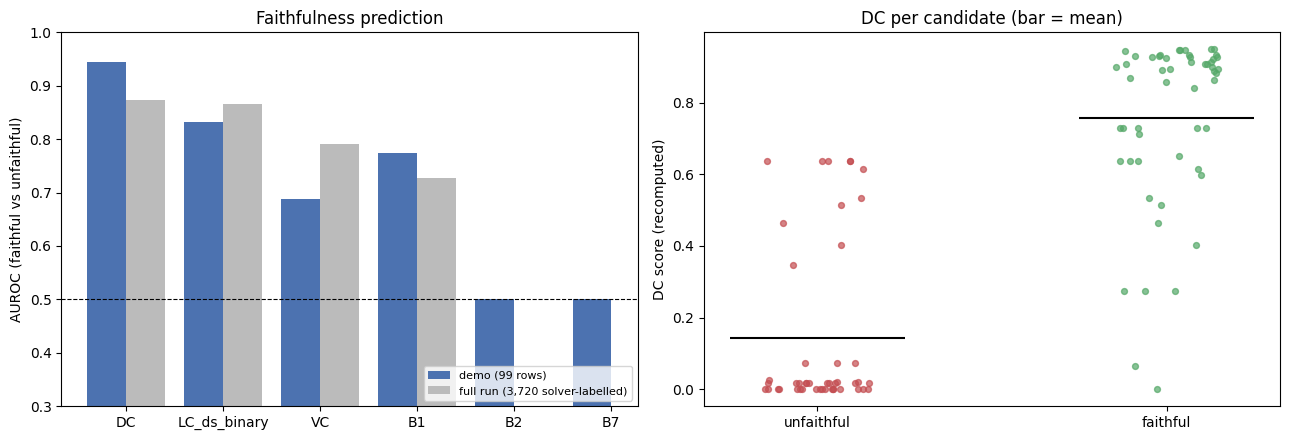


DC mean by corpus / label:
             mean               count           
label    faithful unfaithful faithful unfaithful
corpus                                          
folio       0.868      0.018       20         16
malls       0.530      0.363       19         17
proverqa    0.908      0.005       14         13


In [21]:
lab = df[df.label.isin(["faithful", "unfaithful"])]
y = (lab.label == "faithful").astype(int).values
metrics = ["DC", "LC_ds_binary", "VC", "B1", "B2", "B7"]
auc_demo = {m: (roc_auc_score(y, lab[m].values) if 0 < y.sum() < len(y) else float("nan")) for m in metrics}
H = meta["full_run_headline"]
auc_full = {m: H.get(f"AUROC_solver_{m}", float("nan")) for m in metrics}
summary = pd.DataFrame({"AUROC (demo rows)": auc_demo, "AUROC (full run, solver labels)": auc_full,
                        "AUROC (full run, panel labels)": {m: H.get(f"AUROC_panel_{m}", float("nan")) for m in metrics}})
print(f"labelled demo rows: {len(lab)} (faithful {y.sum()}, unfaithful {len(y) - y.sum()})")
print(summary.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
xs = np.arange(len(metrics))
ax[0].bar(xs - 0.2, [auc_demo[m] for m in metrics], 0.4, label=f"demo ({len(lab)} rows)", color="#4C72B0")
ax[0].bar(xs + 0.2, [auc_full[m] for m in metrics], 0.4, label="full run (3,720 solver-labelled)", color="#BBBBBB")
ax[0].axhline(0.5, ls="--", c="k", lw=0.8)
ax[0].set_xticks(xs, metrics); ax[0].set_ylim(0.3, 1.0); ax[0].set_ylabel("AUROC (faithful vs unfaithful)")
ax[0].set_title("Faithfulness prediction"); ax[0].legend(loc="lower right", fontsize=8)
rng_ = np.random.default_rng(0)
for i, (name, col) in enumerate([("unfaithful", "#C44E52"), ("faithful", "#55A868")]):
    v = lab[lab.label == name].DC.values
    ax[1].scatter(i + rng_.uniform(-0.15, 0.15, len(v)), v, s=18, alpha=0.7, c=col)
    ax[1].hlines(np.mean(v), i - 0.25, i + 0.25, colors="k")
ax[1].set_xticks([0, 1], ["unfaithful", "faithful"]); ax[1].set_ylabel("DC score (recomputed)")
ax[1].set_title("DC per candidate (bar = mean)")
plt.tight_layout(); plt.show()

print("\nDC mean by corpus / label:")
print(lab.groupby(["corpus", "label"]).DC.agg(["mean", "count"]).round(3).unstack())